# TP Final — Detección de sub-declaración de ingresos (ARCA)


Dataset: *Adult / Census Income* (UCI), reinterpretado para este escenario ficticio.

Este notebook retoma el trabajo desde la **Parte 3 de la consigna (Pipeline de trabajo)**. Las partes 1 y 2 (justificación del dataset, del problema y de las variables) ya fueron presentadas y validadas por la cátedra; acá se avanza sobre EDA, limpieza, separación train/test, baseline y primeros modelos.


## 0. Entorno y dependencias


**Cómo usarlo (una sola vez):**
1. Correr las dos celdas de esta sección.
2. Ir al selector de kernel del notebook (arriba a la derecha, o `Kernel → Change Kernel`) y elegir **`Python (tp-arca)`**.
3. `Restart & Run All` para que el resto del notebook corra ya dentro del entorno aislado.

Si se saltea el paso 2, el `.venv` se crea igual y las dependencias quedan instaladas ahí, pero el resto de las celdas van a seguir corriendo con el kernel que ya estaba activo (típicamente porque ya se corrió una vez este notebook y ese es justamente el entorno que armamos).

In [3]:
import sys
import subprocess
import pathlib

VENV_DIR = pathlib.Path(".venv")

if not VENV_DIR.exists():
    subprocess.run([sys.executable, "-m", "venv", str(VENV_DIR)], check=True)
    print(f"Entorno virtual creado en: {VENV_DIR.resolve()}")
else:
    print(f"Ya existe un entorno virtual en: {VENV_DIR.resolve()}")

VENV_PYTHON = VENV_DIR / ("Scripts/python.exe" if sys.platform == "win32" else "bin/python")
print("Intérprete del venv:", VENV_PYTHON.resolve())


Ya existe un entorno virtual en: /Users/agustinronda/Facultad/Machine Learning/final/repo-feli/ML_TP_FInal/.venv
Intérprete del venv: /Library/Frameworks/Python.framework/Versions/3.13/bin/python3.13
Ya existe un entorno virtual en: /home/feli/Documents/ITBA/ML/TP_FInal/.venv
Intérprete del venv: /usr/bin/python3.12


In [4]:
REQUIREMENTS = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scipy",
    "scikit-learn",
    "ipykernel",
    "joblib",
]

with open("requirements.txt", "w") as f:
    f.write("\n".join(REQUIREMENTS) + "\n")

subprocess.run([str(VENV_PYTHON), "-m", "pip", "install", "--upgrade", "pip", "-q"], check=True)
subprocess.run([str(VENV_PYTHON), "-m", "pip", "install", "-r", "requirements.txt", "-q"], check=True)

try:
    subprocess.run(
        [str(VENV_PYTHON), "-m", "ipykernel", "install", "--user",
         "--name", "tp-arca", "--display-name", "Python (tp-arca)"],
        check=True,
    )
    print("Dependencias instaladas y kernel 'Python (tp-arca)' registrado y disponible para seleccionar.")
except subprocess.CalledProcessError as e:
    print("Dependencias instaladas. No se pudo registrar el kernel automáticamente:", e)
    print("Se puede registrar a mano corriendo:")
    print(f"  {VENV_PYTHON} -m ipykernel install --user --name tp-arca --display-name 'Python (tp-arca)'")


Installed kernelspec tp-arca in /home/feli/.local/share/jupyter/kernels/tp-arca
Dependencias instaladas y kernel 'Python (tp-arca)' registrado y disponible para seleccionar.


In [5]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)  # esperable con el baseline (siempre predice una sola clase)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 3.1 Carga de datos

El archivo original no trae encabezado, así que asignamos los nombres de columnas según el diccionario del dataset UCI Adult.

In [6]:
COLS = ["age","workclass","fnlwgt","education","education_num","marital_status",
        "occupation","relationship","race","sex","capital_gain","capital_loss",
        "hours_per_week","native_country","income"]

df = pd.read_csv("adult.csv", header=None, names=COLS, skipinitialspace=True)
print(df.shape)
df.head()


(32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3.2 Análisis exploratorio (EDA)

### 3.2.1 Calidad de datos: tipos, nulos, duplicados

El dataset no tiene `NaN` explícitos, pero usa el string `"?"` como marca de dato faltante en variables categóricas.

In [7]:
print(df.dtypes)
print()
for c in df.select_dtypes(include="object").columns:
    n = (df[c] == "?").sum()
    if n > 0:
        print(f"{c}: {n} faltantes ({n/len(df)*100:.2f}%)")

print("\nDuplicados exactos:", df.duplicated().sum())


age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

workclass: 1836 faltantes (5.64%)
occupation: 1843 faltantes (5.66%)
native_country: 583 faltantes (1.79%)

Duplicados exactos: 24


/tmp/ipykernel_5196/2028227014.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


**Decisión:** `workclass` y `occupation` faltan casi siempre juntas (cuando falta una, falta la otra en 1836 de 1843 casos), lo cual sugiere que la falta de dato no es aleatoria: probablemente corresponde a personas sin relación de dependencia formal. Por eso, en vez de imputar por la moda o eliminar esas filas (perderíamos ~7% de los datos y probablemente un patrón real), las vamos a imputar con una categoría explícita `"Sin_dato"`, preservando la señal de que el dato falta.

`native_country` también tiene faltantes (1.79%), pero la vamos a eliminar por completo más abajo — ver justificación en 3.3.

### 3.2.2 Balance del target

El target real de negocio es *"¿el declarante gana más del umbral?"*, que en este dataset corresponde a `income`.

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


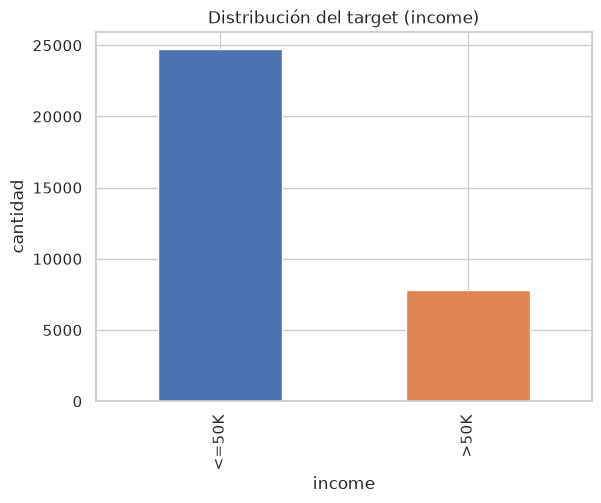

In [8]:
df["target"] = (df["income"] == ">50K").astype(int)
print(df["income"].value_counts(normalize=True))

ax = df["income"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Distribución del target (income)")
ax.set_ylabel("cantidad")
plt.show()


Confirma lo que ya habíamos anticipado en la Entrega 1: desbalance ~76% / 24%. Esto va a condicionar tanto el baseline como las métricas que usemos para evaluar (accuracy sola no alcanza).

### 3.2.3 Variables numéricas: distribución y relación con el target

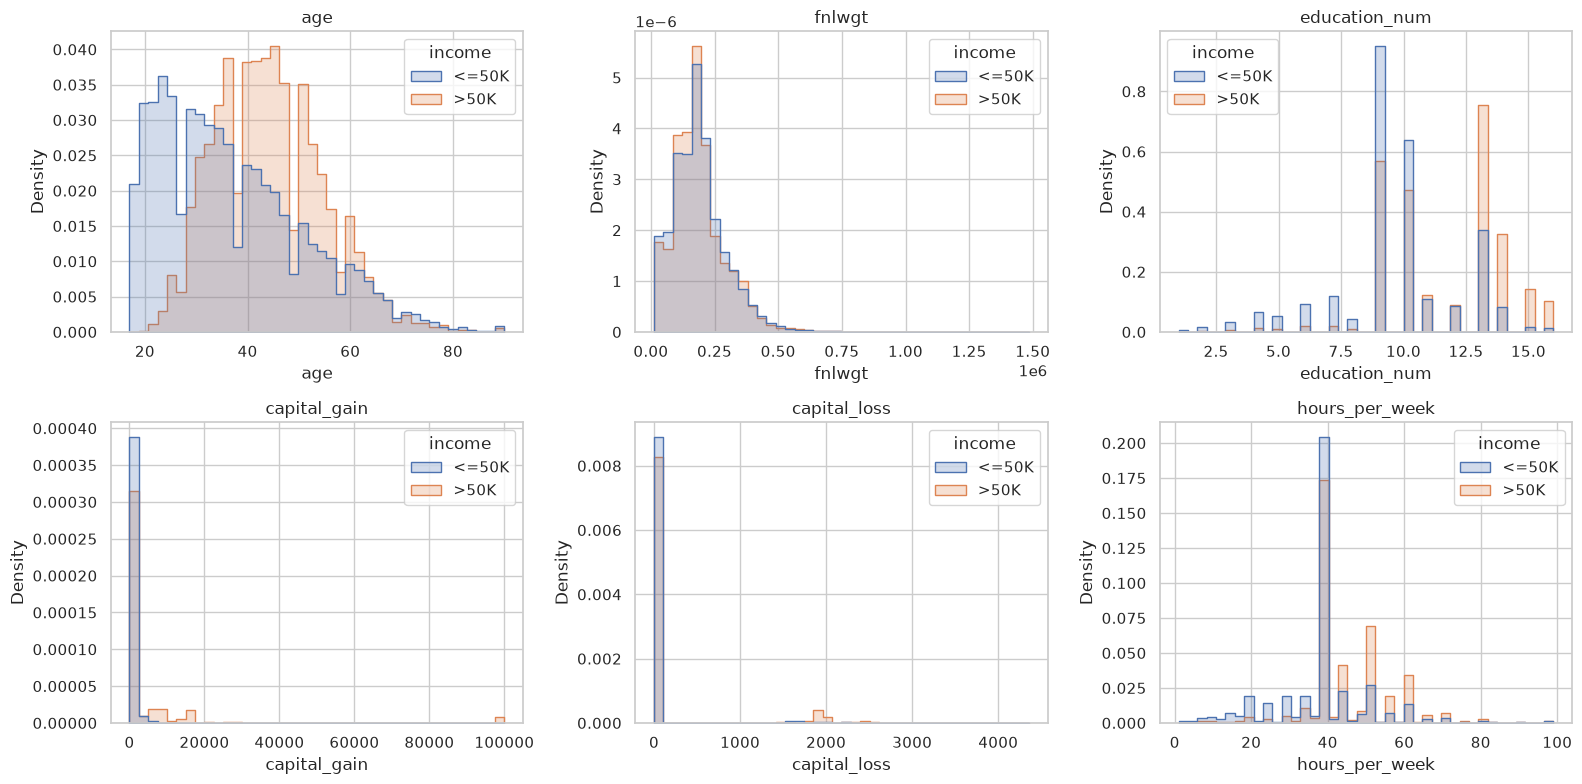

In [9]:
num_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=c, hue="income", bins=40, ax=ax, element="step", stat="density", common_norm=False)
    ax.set_title(c)
plt.tight_layout()
plt.show()


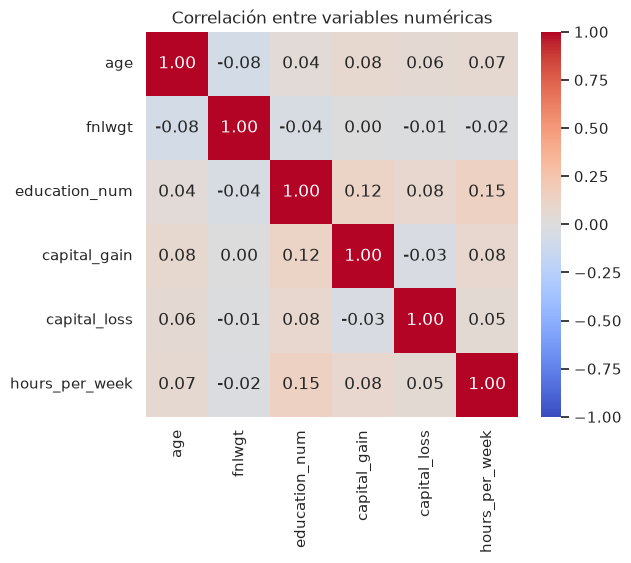

Correlación punto-biserial con el target:
  age              r=+0.234  p=0.0e+00
  fnlwgt           r=-0.009  p=8.8e-02
  education_num    r=+0.335  p=0.0e+00
  capital_gain     r=+0.223  p=0.0e+00
  capital_loss     r=+0.151  p=2.7e-164
  hours_per_week   r=+0.230  p=0.0e+00


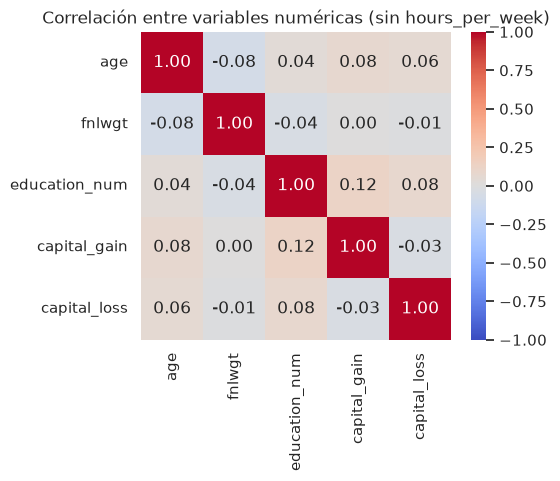

In [ ]:
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.show()

print("Correlación punto-biserial con el target:")
for c in num_cols:
    r, p = pointbiserialr(df["target"], df[c])
    print(f"  {c:16s} r={r:+.3f}  p={p:.1e}")

# Sin contar horas per week, :
corre = df[num_cols].drop(columns="hours_per_week").corr()
plt.figure(figsize=(5,4))
sns.heatmap(corre, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas ")
plt.show()

**Lectura:**
- No hay multicolinealidad fuerte entre las numéricas (todas las correlaciones cruzadas son bajas).
- `education_num` (r≈0.34), `age`, `capital_gain`, `hours_per_week` (r≈0.23) y `capital_loss` (r≈0.15) están asociadas al target.
- `fnlwgt` prácticamente no correlaciona con el target (r≈-0.01, no significativa). Esto confirma lo que ya habíamos señalado en la Entrega 1: es un peso muestral del censo, no una característica del individuo, y **no tiene sentido en este problema** (en producción no existiría un "peso de encuesta" por declarante). Se descarta.
- `hours_per_week` sí es predictiva (r≈0.23), pero **la descartamos igual**: no es un dato que vaya a estar disponible en una declaración impositiva real. Preferimos un pipeline con datos que existan en producción antes que una métrica más alta con una variable que no vamos a tener (esto lo retomamos en la sección 4, riesgos y uso real).

### 3.2.4 Variables categóricas: relación con el target

Usamos **V de Cramér** como medida de asociación (más apropiada que la correlación para variables categóricas).

relationship      0.453585
marital_status    0.447404
education         0.368838
occupation        0.351892
sex               0.215904
workclass         0.179208
race              0.100812
native_country    0.098705
dtype: float64


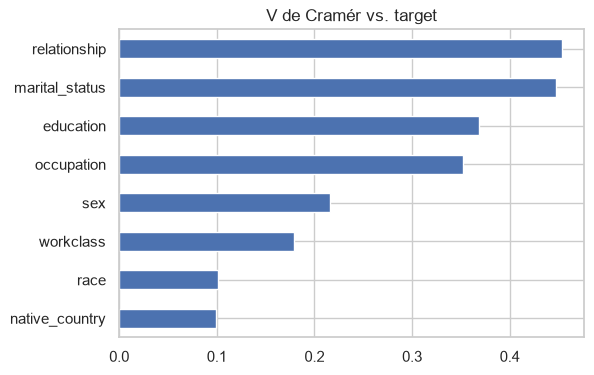

In [9]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = ["workclass", "education", "marital_status", "occupation",
            "relationship", "race", "sex", "native_country"]

assoc = pd.Series({c: cramers_v(df[c], df["income"]) for c in cat_cols}).sort_values(ascending=False)
print(assoc)

assoc.plot(kind="barh", figsize=(6,4))
plt.title("V de Cramér vs. target")
plt.gca().invert_yaxis()
plt.show()


**Lectura:**
- `relationship`, `marital_status`, `occupation` y `education` son las más asociadas al target.
- `race` (V≈0.10) y `native_country` (V≈0.10) tienen asociación débil con el target **además** de los problemas ya señalados en la Entrega 1 (variables poco pertinentes o mal representadas para el contexto argentino). Esto refuerza la decisión de descartarlas — no perdemos poder predictivo relevante.
- `education` está perfectamente redundada por `education_num` (chequeo abajo), así que nos quedamos solo con la versión numérica ordinal.

In [10]:
print(df.groupby("education")["education_num"].unique().sort_values())


education
Preschool        [1]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
10th             [6]
11th             [7]
12th             [8]
HS-grad          [9]
Some-college    [10]
Assoc-voc       [11]
Assoc-acdm      [12]
Bachelors       [13]
Masters         [14]
Prof-school     [15]
Doctorate       [16]
Name: education_num, dtype: object


### 3.2.5 Nota sobre `native_country`

Se había dejado pendiente en la Entrega 1. Lo cuantificamos acá:

In [11]:
print(f"% United-States: {(df['native_country']=='United-States').mean()*100:.1f}%")
print(f"Cantidad de categorías distintas: {df['native_country'].nunique()}")
df["native_country"].value_counts(normalize=True).head(8) * 100


% United-States: 89.6%
Cantidad de categorías distintas: 42


native_country
United-States    89.585701
Mexico            1.974755
?                 1.790486
Philippines       0.608089
Germany           0.420749
Canada            0.371610
Puerto-Rico       0.350112
El-Salvador       0.325543
Name: proportion, dtype: float64

**Decisión: se descarta.** Tres motivos combinados:
1. Asociación débil con el target (V≈0.10, similar a `race`, que ya descartamos por motivos parecidos).
2. ~90% de los casos son `United-States` y el resto se reparte en 40 categorías con muy pocos casos cada una — casi no aporta variabilidad utilizable, y encima el desbalance geográfico responde al contexto de EE.UU., no al argentino (mismo problema que señalamos para `race`).
3. Reinterpretarla como binaria (`"local"` vs. `"extranjero"`) es técnicamente posible, pero dado el punto 1 el aporte esperado es marginal, así que no se justifica la complejidad extra ni el 1.8% de imputación que exigiría. Si el análisis de errores más adelante muestra un patrón sistemático relacionado con origen, se puede reconsiderar.

### 3.2.6 Nota sobre `sex` y `race`: variables sensibles

`sex` sí tiene asociación relevante con el target (V≈0.22) y una disparidad grande en la tasa de la clase positiva:

In [12]:
print(df.groupby("sex")["target"].mean())


sex
Female    0.109461
Male      0.305737
Name: target, dtype: float64


Por ahora la mantenemos como feature (tiene poder predictivo real en el dataset y no la habíamos marcado como problemática en la Entrega 1), pero queda anotada como **riesgo a monitorear**: un modelo de riesgo fiscal que aprenda a asociar género con sospecha de sub-declaración es un problema ético y legal serio si eso se traduce en más auditorías a un grupo por su género en lugar de por su conducta. Lo retomamos en la sección 4 (riesgos).

## 3.3 Limpieza y selección de variables

Resumen de decisiones:

| Variable | Decisión | Motivo |
|---|---|---|
| `fnlwgt` | eliminar | peso muestral del censo, sin sentido a nivel individuo, sin correlación con el target |
| `race` | eliminar | no se usa institucionalmente en Argentina para este tipo de análisis; asociación débil |
| `native_country` | eliminar | asociación débil, 90% concentrado en una categoría, contexto no aplica a Argentina |
| `hours_per_week` | eliminar | no disponible en una declaración impositiva real (no existiría en producción) |
| `education` | eliminar | redundante con `education_num` |
| `workclass`, `occupation` | mantener, imputar `"?"` → `"Sin_dato"` | faltante no aleatorio, aporta info |
| resto | mantener | ver EDA |


In [13]:
DROP_COLS = ["fnlwgt", "race", "native_country", "hours_per_week", "education", "income"]

df_clean = df.drop(columns=DROP_COLS).copy()
df_clean = df_clean.drop_duplicates()

for c in ["workclass", "occupation"]:
    df_clean[c] = df_clean[c].replace("?", "Sin_dato")

print(df_clean.shape)
df_clean.head()


(22427, 10)


,age,workclass,education_num,marital_status,occupation,relationship,sex,capital_gain,capital_loss,target
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,0


## 3.4 Separación train / test

Usamos **partición estratificada** por el target: como el desbalance es 76/24, un split aleatorio simple podría dejar proporciones distintas en train y test por azar, sobre todo si en algún fold quedan pocos positivos. Con `stratify` forzamos que ambos conjuntos mantengan la misma proporción de clases que el dataset completo.

In [14]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["target"])
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.mean().round(3))
print("Test: ", X_test.shape, y_test.mean().round(3))


Train: (17941, 9) 0.261
Test:  (4486, 9) 0.261


## 3.5 Preprocesamiento

Armamos un `ColumnTransformer` para no tener que normalizar/encodear "a mano" y para que el mismo pipeline se pueda aplicar en train y test sin fugas de información (el `fit` del scaler y del encoder se hace **solo** con train).

- Numéricas → `StandardScaler` (media 0, desvío 1). Necesario para la regresión logística; no afecta a Random Forest pero no molesta tenerlo en el mismo pipeline.
- Categóricas → `OneHotEncoder` (con `handle_unknown="ignore"` por si en test aparece alguna categoría rara no vista en train).

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = ["age", "education_num", "capital_gain", "capital_loss"]
categorical_features = ["workclass", "marital_status", "occupation", "relationship", "sex"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


### 3.5.1 Vista del dataset ya procesado

Antes de seguir, vale la pena ver cómo queda la matriz que realmente entra al modelo: numéricas ya escaladas y categóricas ya en one-hot. Ajustamos el `preprocessor` solo con train (para no filtrar información de test) y mostramos un `head()`.

In [16]:
preprocessor_fitted = preprocessor.fit(X_train)
feature_names = preprocessor_fitted.get_feature_names_out()

X_train_transformed = preprocessor_fitted.transform(X_train)
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

X_train_proc = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
print(f"Forma final: {X_train_proc.shape[0]} filas x {X_train_proc.shape[1]} columnas "
      f"({len(numeric_features)} numéricas escaladas + {X_train_proc.shape[1]-len(numeric_features)} dummies de one-hot)")
X_train_proc.head()


Forma final: 17941 filas x 43 columnas (4 numéricas escaladas + 39 dummies de one-hot)


,num__age,num__education_num,num__capital_gain,num__capital_loss,cat__workclass_Federal-gov,cat__workclass_Local-gov,cat__workclass_Never-worked,cat__workclass_Private,cat__workclass_Self-emp-inc,cat__workclass_Self-emp-not-inc,cat__workclass_Sin_dato,cat__workclass_State-gov,cat__workclass_Without-pay,cat__marital_status_Divorced,cat__marital_status_Married-AF-spouse,cat__marital_status_Married-civ-spouse,cat__marital_status_Married-spouse-absent,cat__marital_status_Never-married,cat__marital_status_Separated,cat__marital_status_Widowed,cat__occupation_Adm-clerical,cat__occupation_Armed-Forces,cat__occupation_Craft-repair,cat__occupation_Exec-managerial,cat__occupation_Farming-fishing,cat__occupation_Handlers-cleaners,cat__occupation_Machine-op-inspct,cat__occupation_Other-service,cat__occupation_Priv-house-serv,cat__occupation_Prof-specialty,cat__occupation_Protective-serv,cat__occupation_Sales,cat__occupation_Sin_dato,cat__occupation_Tech-support,cat__occupation_Transport-moving,cat__relationship_Husband,cat__relationship_Not-in-family,cat__relationship_Other-relative,cat__relationship_Own-child,cat__relationship_Unmarried,cat__relationship_Wife,cat__sex_Female,cat__sex_Male
13656,-0.786339,-0.400272,-0.172626,-0.261625,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
31906,0.527302,0.673162,-0.172626,-0.261625,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2571,-1.443159,-0.042460,-0.172626,-0.261625,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4060,-0.056538,1.030974,-0.172626,-0.261625,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20595,0.965183,-0.400272,0.339869,-0.261625,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 3.6 Baseline y primeros modelos

**Principio metodológico para todo lo que sigue:** el test se toca una única vez, al final, para reportar resultados — no para tomar decisiones durante el desarrollo (comparar modelos, elegir hiperparámetros, validar una métrica nueva). Para eso está la validación cruzada: nos deja comparar y elegir usando solamente `X_train`/`y_train`, sin gastar el test antes de tiempo.

Entonces: el baseline y los primeros modelos (regresión logística y Random Forest, con hiperparámetros por defecto) se evalúan acá con `cross_validate` sobre train. El baseline predice siempre la clase mayoritaria (`<=50K`); para accuracy esto equivale, a grandes rasgos, a la proporción de la clase más numerosa (~76%, ya lo vimos en el EDA). Igual que con los modelos, lo confirmamos con la misma metodología (CV) para que la comparación sea pareja.

In [17]:
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

lr_pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
# n_estimators moderado acá (100) solo para que esta primera pasada de sanity-check sea rápida;
# el número de árboles se vuelve a discutir en la búsqueda de hiperparámetros (3.9).
rf_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))])
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

cv_results = {}
for name, est in [("Baseline", dummy), ("Regresión Logística", lr_pipe), ("Random Forest", rf_pipe)]:
    cv = cross_validate(est, X_train, y_train, cv=5, scoring=scoring, n_jobs=1)
    cv_results[name] = {m: cv[f"test_{m}"].mean() for m in scoring}

cv_comparison = pd.DataFrame(cv_results).T.round(3)
cv_comparison


,accuracy,precision,recall,f1,roc_auc
Baseline,0.739,0.000,0.000,0.000,0.500
Regresión Logística,0.832,0.722,0.579,0.642,0.889
Random Forest,0.800,0.629,0.569,0.598,0.849


**Lectura (todo esto sobre train, vía CV — todavía no vimos test):**
- El baseline, como se esperaba, tiene accuracy "gratis" (~76%) pero recall y F1 en cero: nunca marca a nadie como sospechoso. Cualquier modelo tiene que superarlo en recall/F1/ROC-AUC, no solo en accuracy.
- La regresión logística supera al Random Forest "de fábrica" en casi todas las métricas. Con hiperparámetros por defecto (profundidad libre, pocos árboles), el RF probablemente está sobreajustando un poco sobre el espacio disperso de las variables one-hot. Lo retomamos en la búsqueda de hiperparámetros (3.9) — buen ejemplo de por qué la consigna pide no usar modelos complejos "porque sí": acá, sin tunear, el modelo más simple gana.

## 3.7 Predicciones con probabilidad y ranking de riesgo

El equipo de auditoría necesita una lista ordenada por riesgo, no un sí/no binario — por eso usamos `predict_proba` en vez de quedarnos solo con `predict`. Para ilustrar cómo se ve ese ranking sin gastar el test, usamos `cross_val_predict`: cada fila del train queda predicha por un modelo que **no la vio** durante el entrenamiento de ese fold (predicción "out-of-fold"), así que el ranking es honesto aunque sea sobre datos de train.

In [18]:
from sklearn.model_selection import cross_val_predict

proba_oof_lr = cross_val_predict(lr_pipe, X_train, y_train, cv=5, method="predict_proba", n_jobs=1)[:, 1]
proba_oof_rf = cross_val_predict(rf_pipe, X_train, y_train, cv=5, method="predict_proba", n_jobs=1)[:, 1]

ranking_oof_lr = pd.DataFrame(
    {"y_real": y_train.values, "proba_subdeclaracion": proba_oof_lr}, index=X_train.index
).sort_values("proba_subdeclaracion", ascending=False)

print("Top 15 según riesgo estimado (regresión logística, out-of-fold sobre train):")
ranking_oof_lr.head(1000)


Top 15 según riesgo estimado (regresión logística, out-of-fold sobre train):


,y_real,proba_subdeclaracion
26442,1,1.000000
25611,1,1.000000
12677,1,1.000000
22361,1,1.000000
2319,1,1.000000
...,...,...
13547,1,0.864085
24223,1,0.863656
30363,1,0.863614
22639,0,0.863541


Con esta tabla el equipo de auditoría podría, por ejemplo, mirar primero los 100 o 1000 casos con `proba_subdeclaracion` más alta. Esa idea es la base de las métricas de negocio de la próxima sección.

## 3.8 Métricas de negocio: ¿qué tan bien se usarían los recursos de auditoría?

Accuracy, precision, recall, F1 y ROC-AUC son necesarias pero no cuentan toda la historia: no reflejan que en producción el output que se usa es el **ranking de probabilidades**, no una clasificación binaria. Definimos dos métricas pensadas específicamente para este caso de uso, y las validamos acá con las probabilidades out-of-fold de la sección anterior (train, no test).

**1. Precisión ponderada por probabilidad (`weighted_precision`)**

Si el equipo de auditoría dedica más atención a los casos con `proba` más alta —en proporción a la probabilidad, no con un corte binario—, entonces lo que importa es qué fracción de ese "esfuerzo ponderado" cae sobre sub-declarantes reales:

$$\text{weighted\_precision} = \frac{\sum_i p_i \cdot y_i}{\sum_i p_i}$$

**2. Precisión sobre el top-N (`precision_at_n`)**

Más simple y más fácil de explicar en la Parte 5: de los N declarantes con mayor probabilidad estimada (los primeros que el equipo revisaría), ¿qué porcentaje son efectivamente sub-declarantes? La calculamos para N=100 y N=1000.

In [19]:
def weighted_precision(y_true, y_proba):
    """Fracción de la 'masa de probabilidad' repartida por el modelo que efectivamente
    cae sobre sub-declarantes reales. Pensada para un escenario donde el esfuerzo de
    auditoría se asigna en proporción a la probabilidad estimada, no con un corte binario."""
    y_true = np.asarray(y_true, dtype=float)
    y_proba = np.asarray(y_proba, dtype=float)
    denom = y_proba.sum()
    if denom == 0:
        return float("nan")  # el modelo no asignó probabilidad a la clase positiva en ningún caso
    return float((y_proba * y_true).sum() / denom)


def precision_at_n(y_true, y_proba, n):
    """De los N casos con mayor probabilidad estimada, qué fracción son positivos reales.
    Simula: 'el equipo de auditoría revisa los N casos más riesgosos, ¿cuántos son ciertos?'"""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)[:n]
    return float(y_true[order].mean())


def business_metrics(y_true, y_proba, ns=(100, 1000)):
    out = {"weighted_precision": weighted_precision(y_true, y_proba)}
    for n in ns:
        out[f"precision_at_{n}"] = precision_at_n(y_true, y_proba, n)
    return out


print("Validación con probabilidades out-of-fold sobre train (todavía sin tocar test):")
for name, proba in [("Regresión Logística", proba_oof_lr), ("Random Forest", proba_oof_rf)]:
    bm = business_metrics(y_train.values, proba)
    print(name, {k: round(v, 3) for k, v in bm.items()})


Validación con probabilidades out-of-fold sobre train (todavía sin tocar test):
Regresión Logística {'weighted_precision': 0.567, 'precision_at_100': 1.0, 'precision_at_1000': 0.96}
Random Forest {'weighted_precision': 0.566, 'precision_at_100': 0.98, 'precision_at_1000': 0.918}


Ya sobre train (out-of-fold) se ve el mismo patrón que con las métricas clásicas: la regresión logística está algo mejor calibrada que el Random Forest sin tunear. El top-100 de ambos modelos tiene precisión altísima igual — cuando el modelo está muy seguro, casi siempre acierta; el problema está más "en el medio" del ranking, que es justo lo que la `weighted_precision` captura al mirar todos los casos. Los números definitivos (sobre test) quedan para la sección 3.10, después de tunear.

## 3.9 Búsqueda de hiperparámetros

Probamos combinaciones de hiperparámetros con `RandomizedSearchCV` (3 folds), todo sobre `X_train`/`y_train` — el test sigue sin tocarse. Incluimos `class_weight="balanced"` como opción dado el desbalance de clases.

Usamos **scoring múltiple**: ROC-AUC como criterio principal para elegir el mejor modelo (`refit`), porque es una métrica de ranking robusta y no depende de un recorte arbitrario como el N del top-N. Además reportamos, para cada combinación, las métricas de negocio (`weighted_precision`, `precision_at_100`) a modo diagnóstico — así vemos si optimizar por ROC-AUC también mueve en la dirección correcta a las métricas que realmente le importan al caso de uso, sin optimizar directamente sobre un N que podría ser ruidoso con pocos folds.

Nota técnica: para Random Forest usamos `n_jobs=1` en el clasificador y el paralelismo en la búsqueda (`RandomizedSearchCV(n_jobs=-1)`) — paralelizar en los dos niveles a la vez satura los cores en vez de acelerar.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

scoring_dict = {
    "roc_auc": "roc_auc",
    "weighted_precision": make_scorer(weighted_precision, response_method="predict_proba"),
    "precision_at_100": make_scorer(precision_at_n, response_method="predict_proba", n=100),
}

lr_search_pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
lr_param_dist = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}
lr_search = RandomizedSearchCV(
    lr_search_pipe, lr_param_dist, n_iter=8, scoring=scoring_dict, refit="roc_auc",
    cv=3, random_state=RANDOM_STATE, n_jobs=-1,
)
lr_search.fit(X_train, y_train)

best_idx = lr_search.best_index_
cvres = lr_search.cv_results_
print("Mejores hiperparámetros (Regresión Logística):", lr_search.best_params_)
print("CV — ROC-AUC:", round(cvres["mean_test_roc_auc"][best_idx], 3),
      "| weighted_precision:", round(cvres["mean_test_weighted_precision"][best_idx], 3),
      "| precision_at_100:", round(cvres["mean_test_precision_at_100"][best_idx], 3))


Mejores hiperparámetros (Regresión Logística): {'clf__class_weight': None, 'clf__C': 10}
CV — ROC-AUC: 0.889 | weighted_precision: 0.568 | precision_at_100: 0.983


In [21]:
rf_search_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))])
rf_param_dist = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [8, 16],
    "clf__min_samples_leaf": [1, 5, 20],
    "clf__class_weight": [None, "balanced"],
}
rf_search = RandomizedSearchCV(
    rf_search_pipe, rf_param_dist, n_iter=6, scoring=scoring_dict, refit="roc_auc",
    cv=3, random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train, y_train)

best_idx = rf_search.best_index_
cvres = rf_search.cv_results_
print("Mejores hiperparámetros (Random Forest):", rf_search.best_params_)
print("CV — ROC-AUC:", round(cvres["mean_test_roc_auc"][best_idx], 3),
      "| weighted_precision:", round(cvres["mean_test_weighted_precision"][best_idx], 3),
      "| precision_at_100:", round(cvres["mean_test_precision_at_100"][best_idx], 3))


Mejores hiperparámetros (Random Forest): {'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_depth': 16, 'clf__class_weight': None}
CV — ROC-AUC: 0.904 | weighted_precision: 0.568 | precision_at_100: 1.0


**Lectura (todavía sobre CV/train):** el tuneo le hace bien especialmente a Random Forest — con `max_depth` y `min_samples_leaf` moderados deja de sobreajustar y pasa a competir de igual a igual con la regresión logística, o incluso superarla, según la métrica. Con esto ya elegimos y fijamos los hiperparámetros de ambos modelos usando únicamente train. Recién en la próxima sección los llevamos a test.

## 3.10 Evaluación out-of-fold de los modelos tuneados

Los hiperparámetros ya fueron seleccionados mediante validación cruzada utilizando
solamente el conjunto de entrenamiento.

Para evaluar los modelos elegidos sin utilizar el conjunto de test, generamos
predicciones out-of-fold. Cada observación es predicha por un modelo que fue
entrenado sin incluir esa observación.

Esto permite obtener predicciones honestas para realizar la comparación de modelos,
el análisis de errores y el análisis por cohortes.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

cv_oof = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

best_lr = lr_search.best_estimator_
best_rf = rf_search.best_estimator_

proba_oof_lr_tuned = cross_val_predict(
    best_lr,
    X_train,
    y_train,
    cv=cv_oof,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

proba_oof_rf_tuned = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=cv_oof,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

pred_oof_lr_tuned = (proba_oof_lr_tuned >= 0.5).astype(int)
pred_oof_rf_tuned = (proba_oof_rf_tuned >= 0.5).astype(int)

print("Predicciones out-of-fold generadas.")
print("Cantidad de observaciones:", len(y_train))

Predicciones out-of-fold generadas.
Cantidad de observaciones: 17941


### 3.10.1 Comparación de métricas

Se comparan los modelos tuneados mediante métricas de clasificación, métricas de
ranking y métricas asociadas a la capacidad limitada de auditoría.

Además de las métricas tradicionales, se reportan:

- **PR-AUC:** resume la relación entre precision y recall y resulta útil ante clases desbalanceadas.
- **Precision@1000:** proporción de positivos reales dentro de los 1000 casos con mayor riesgo.
- **Recall@1000:** proporción de todos los positivos que aparece dentro de esos 1000 casos.
- **Lift@1000:** mejora de Precision@1000 respecto de seleccionar casos al azar.

In [23]:
def recall_at_n(y_true, y_proba, n):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    n = min(n, len(y_true))
    top_indices = np.argsort(-y_proba)[:n]

    total_positives = y_true.sum()

    if total_positives == 0:
        return np.nan

    return float(y_true[top_indices].sum() / total_positives)


def lift_at_n(y_true, y_proba, n):
    base_rate = np.asarray(y_true).mean()

    if base_rate == 0:
        return np.nan

    return precision_at_n(y_true, y_proba, n) / base_rate


def evaluate_oof_model(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "weighted_precision": weighted_precision(y_true, y_proba),
        "precision_at_100": precision_at_n(y_true, y_proba, 100),
        "precision_at_1000": precision_at_n(y_true, y_proba, 1000),
        "recall_at_1000": recall_at_n(y_true, y_proba, 1000),
        "lift_at_1000": lift_at_n(y_true, y_proba, 1000),
    }


metrics_tuned = pd.DataFrame({
    "Regresión Logística": evaluate_oof_model(
        y_train,
        pred_oof_lr_tuned,
        proba_oof_lr_tuned,
    ),
    "Random Forest": evaluate_oof_model(
        y_train,
        pred_oof_rf_tuned,
        proba_oof_rf_tuned,
    ),
}).T

metrics_tuned.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc,weighted_precision,precision_at_100,precision_at_1000,recall_at_1000,lift_at_1000
Regresión Logística,0.832,0.722,0.581,0.644,0.889,0.760,0.567,1.0,0.961,0.205,3.683
Random Forest,0.848,0.795,0.561,0.657,0.904,0.805,0.569,1.0,0.998,0.213,3.825


### Interpretación de la comparación

El Random Forest tuneado obtuvo un ROC-AUC de **0.904**, superior al **0.889**
obtenido por la regresión logística. También presentó un PR-AUC mayor
(**0.805 frente a 0.760**) y un F1 ligeramente superior
(**0.657 frente a 0.644**).

En términos del caso de uso, el Random Forest alcanzó una Precision@1000 de
**0.998**. Esto significa que, entre los 1000 casos con mayor riesgo estimado,
aproximadamente **998 pertenecen realmente a la clase positiva**.

El Recall@1000 fue de **0.213**, por lo que esos 1000 casos contienen
aproximadamente el **21.3% de todos los casos positivos** presentes en el
conjunto de validación.

El Lift@1000 fue de **3.825**. Esto indica que la precisión obtenida al seleccionar
los 1000 casos con mayor score es aproximadamente **3.8 veces mayor que la que
se obtendría seleccionando 1000 casos al azar**.

## 3.11 Análisis de errores

Analizamos las predicciones out-of-fold del Random Forest tuneado, que fue el modelo
seleccionado.

Se distinguen cuatro resultados:

- verdadero negativo;
- falso positivo;
- falso negativo;
- verdadero positivo.

Los falsos positivos representan personas que serían priorizadas innecesariamente.
Los falsos negativos representan personas de la clase positiva que el modelo podría
dejar fuera de la auditoría.

In [24]:
analysis_oof = X_train.copy()

analysis_oof["y_real"] = y_train.to_numpy()
analysis_oof["probabilidad"] = proba_oof_rf_tuned
analysis_oof["prediccion"] = pred_oof_rf_tuned

conditions = [
    (analysis_oof["y_real"] == 0) & (analysis_oof["prediccion"] == 0),
    (analysis_oof["y_real"] == 0) & (analysis_oof["prediccion"] == 1),
    (analysis_oof["y_real"] == 1) & (analysis_oof["prediccion"] == 0),
    (analysis_oof["y_real"] == 1) & (analysis_oof["prediccion"] == 1),
]

labels = ["VN", "FP", "FN", "VP"]

analysis_oof["resultado"] = np.select(
    conditions,
    labels,
    default="Sin clasificar",
)

analysis_oof["resultado"].value_counts()

resultado
VN    12583
VP     2624
FN     2057
FP      677
Name: count, dtype: int64

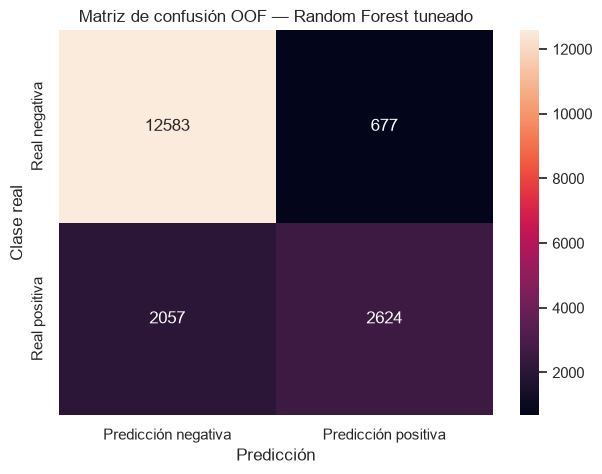

,Predicción negativa,Predicción positiva
Real negativa,12583,677
Real positiva,2057,2624


In [25]:
cm = confusion_matrix(
    analysis_oof["y_real"],
    analysis_oof["prediccion"],
    labels=[0, 1],
)

cm_df = pd.DataFrame(
    cm,
    index=["Real negativa", "Real positiva"],
    columns=["Predicción negativa", "Predicción positiva"],
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.title("Matriz de confusión OOF — Random Forest tuneado")
plt.ylabel("Clase real")
plt.xlabel("Predicción")
plt.show()

cm_df

### 3.11.1 Errores de mayor confianza

No todos los errores son igualmente informativos.

Un falso positivo con probabilidad muy alta indica que el modelo estaba muy seguro
de una predicción incorrecta. Un falso negativo con probabilidad muy baja representa
un positivo real que el modelo consideró de muy bajo riesgo.

In [26]:
columns_to_show = [
    "age",
    "education_num",
    "workclass",
    "occupation",
    "marital_status",
    "relationship",
    "sex",
    "capital_gain",
    "capital_loss",
    "y_real",
    "probabilidad",
    "prediccion",
]

falsos_positivos = (
    analysis_oof
    .query("resultado == 'FP'")
    .sort_values("probabilidad", ascending=False)
)

falsos_negativos = (
    analysis_oof
    .query("resultado == 'FN'")
    .sort_values("probabilidad", ascending=True)
)

print("Falsos positivos con mayor confianza:")
display(falsos_positivos[columns_to_show].head(15))

print("Falsos negativos con mayor confianza:")
display(falsos_negativos[columns_to_show].head(15))

Falsos positivos con mayor confianza:


,age,education_num,workclass,occupation,marital_status,relationship,sex,capital_gain,capital_loss,y_real,probabilidad,prediccion
18453,51,13,Federal-gov,Exec-managerial,Married-civ-spouse,Husband,Male,0,1902,0,0.920300,1
3961,62,9,Self-emp-not-inc,Craft-repair,Married-civ-spouse,Husband,Male,10566,0,0,0.867036,1
20176,63,14,Self-emp-not-inc,Farming-fishing,Married-civ-spouse,Husband,Male,41310,0,0,0.862887,1
6232,90,13,Self-emp-not-inc,Prof-specialty,Married-civ-spouse,Husband,Male,10566,0,0,0.857891,1
25321,66,13,Sin_dato,Sin_dato,Married-civ-spouse,Husband,Male,6767,0,0,0.857805,1
9374,64,10,Private,Exec-managerial,Married-civ-spouse,Wife,Female,10566,0,0,0.857665,1
13790,59,13,Private,Exec-managerial,Married-civ-spouse,Husband,Male,0,2002,0,0.841133,1
11219,70,10,Self-emp-inc,Sales,Married-civ-spouse,Husband,Male,10566,0,0,0.838558,1
28987,57,11,Private,Prof-specialty,Married-civ-spouse,Husband,Male,0,1902,0,0.830726,1
1768,71,9,Private,Protective-serv,Married-civ-spouse,Husband,Male,6767,0,0,0.822031,1


Falsos negativos con mayor confianza:


,age,education_num,workclass,occupation,marital_status,relationship,sex,capital_gain,capital_loss,y_real,probabilidad,prediccion
23273,22,10,Private,Other-service,Never-married,Own-child,Male,0,0,1,0.000473,0
12973,26,9,Private,Adm-clerical,Never-married,Own-child,Male,0,0,1,0.003936,0
31412,47,10,Private,Adm-clerical,Separated,Unmarried,Female,0,0,1,0.004707,0
15966,24,9,Private,Other-service,Separated,Unmarried,Female,0,0,1,0.006626,0
11178,45,9,Private,Other-service,Married-spouse-absent,Unmarried,Female,0,0,1,0.008390,0
26492,26,13,Private,Adm-clerical,Never-married,Own-child,Female,0,0,1,0.009111,0
29187,31,9,Private,Other-service,Divorced,Unmarried,Female,0,0,1,0.009240,0
3763,24,11,Private,Adm-clerical,Never-married,Not-in-family,Male,0,0,1,0.011885,0
18270,27,10,Local-gov,Protective-serv,Never-married,Own-child,Female,0,0,1,0.012176,0
32214,22,3,Local-gov,Handlers-cleaners,Never-married,Other-relative,Male,0,0,1,0.014362,0


In [27]:
numeric_error_profile = (
    analysis_oof
    .groupby("resultado")[
        ["age", "education_num", "capital_gain", "capital_loss"]
    ]
    .agg(["count", "mean", "median"])
    .round(2)
)

numeric_error_profile

age               education_num               capital_gain  \
           count   mean median         count   mean median        count   
resultado                                                                 
FN          2057  43.76   43.0          2057  10.59   10.0         2057   
FP           677  45.40   43.0           677  12.61   13.0          677   
VN         12583  39.10   37.0         12583   9.42    9.0        12583   
VP          2624  45.28   44.0          2624  12.46   13.0         2624   

                          capital_loss                 
              mean median        count    mean median  
resultado                                              
FN          222.57    0.0         2057   88.73    0.0  
FP          549.69    0.0          677  155.21    0.0  
VN          202.47    0.0        12583   76.64    0.0  
VP         8882.96    0.0         2624  378.36    0.0

In [28]:
categorical_columns = [
    "workclass",
    "occupation",
    "marital_status",
    "relationship",
    "sex",
]

for column in categorical_columns:
    print(f"\nDistribución porcentual por tipo de error — {column}")

    table = (
        pd.crosstab(
            analysis_oof[column],
            analysis_oof["resultado"],
            normalize="columns",
        )
        * 100
    )

    table = table.reindex(
        columns=["FP", "FN"],
        fill_value=0,
    )

    display(
        table
        .sort_values("FN", ascending=False)
        .round(1)
        .head(15)
    )


Distribución porcentual por tipo de error — workclass


resultado,FP,FN
workclass,,
Private,47.7,60.0
Self-emp-not-inc,9.9,12.6
Local-gov,13.6,8.2
Self-emp-inc,12.0,5.3
Federal-gov,6.4,5.3
State-gov,8.1,4.4
Sin_dato,2.4,4.2
Never-worked,0.0,0.0
Without-pay,0.0,0.0



Distribución porcentual por tipo de error — occupation


resultado,FP,FN
occupation,,
Exec-managerial,29.5,15.7
Craft-repair,3.1,15.2
Sales,9.3,13.5
Prof-specialty,36.9,13.2
Adm-clerical,5.0,10.0
Transport-moving,0.7,6.3
Machine-op-inspct,1.0,4.9
Other-service,0.4,4.2
Sin_dato,2.4,4.2



Distribución porcentual por tipo de error — marital_status


resultado,FP,FN
marital_status,,
Married-civ-spouse,98.8,68.6
Divorced,0.4,13.0
Never-married,0.6,12.7
Widowed,0.0,2.3
Separated,0.1,1.9
Married-spouse-absent,0.0,1.1
Married-AF-spouse,0.0,0.3



Distribución porcentual por tipo de error — relationship


resultado,FP,FN
relationship,,
Husband,82.3,58.7
Not-in-family,0.9,22.8
Wife,16.2,9.0
Unmarried,0.1,6.6
Own-child,0.1,1.9
Other-relative,0.3,1.1



Distribución porcentual por tipo de error — sex


resultado,FP,FN
sex,,
Male,83.8,78.8
Female,16.2,21.2


## 3.12 Análisis por cohortes

Una métrica global puede ocultar que el modelo funciona mejor para algunos grupos
que para otros.

Se analiza el rendimiento según sexo, edad, educación, disponibilidad de datos
laborales, clase laboral y ocupación.

Las métricas principales son:

- **prevalencia:** proporción real de positivos dentro de la cohorte;
- **precision:** proporción de positivos reales entre los casos marcados;
- **recall:** proporción de positivos de la cohorte que el modelo detecta;
- **FPR:** proporción de negativos de la cohorte clasificados incorrectamente como positivos;
- **FNR:** proporción de positivos de la cohorte que el modelo no detecta;
- **tasa de selección top 1000:** proporción de la cohorte incluida entre los 1000 casos de mayor riesgo.

In [29]:
analysis_oof["age_band"] = pd.cut(
    analysis_oof["age"],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=["Hasta 25", "26-35", "36-45", "46-55", "56-65", "Más de 65"],
)

analysis_oof["education_band"] = pd.cut(
    analysis_oof["education_num"],
    bins=[0, 8, 9, 12, 13, 16],
    labels=[
        "Secundario incompleto",
        "Secundario completo",
        "Estudios superiores incompletos",
        "Grado universitario",
        "Posgrado",
    ],
    include_lowest=True,
)

analysis_oof["datos_laborales"] = np.where(
    (analysis_oof["workclass"] == "Sin_dato")
    | (analysis_oof["occupation"] == "Sin_dato"),
    "Sin dato laboral",
    "Con dato laboral",
)

TOP_N = 1000

top_indices = (
    analysis_oof
    .nlargest(TOP_N, "probabilidad")
    .index
)

analysis_oof["top_1000"] = analysis_oof.index.isin(top_indices)

analysis_oof[
    ["age", "age_band", "education_num", "education_band", "datos_laborales"]
].head()

,age,age_band,education_num,education_band,datos_laborales
13656,30,26-35,9,Secundario completo,Con dato laboral
31906,48,46-55,12,Estudios superiores incompletos,Con dato laboral
2571,21,Hasta 25,10,Estudios superiores incompletos,Sin dato laboral
4060,40,36-45,13,Grado universitario,Con dato laboral
20595,54,46-55,9,Secundario completo,Sin dato laboral


In [30]:
def metrics_by_cohort(data, column, min_size=50):
    rows = []

    for cohort, group in data.groupby(
        column,
        dropna=False,
        observed=True,
    ):
        y_true_group = group["y_real"].to_numpy()
        y_pred_group = group["prediccion"].to_numpy()

        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1],
        ).ravel()

        n = len(group)
        positives = int(y_true_group.sum())
        negatives = n - positives

        selected = group[group["top_1000"]]

        rows.append({
            "variable": column,
            "cohorte": str(cohort),
            "n": n,
            "positivos": positives,
            "negativos": negatives,
            "prevalencia": positives / n if n else np.nan,
            "score_promedio": group["probabilidad"].mean(),
            "precision": tp / (tp + fp) if (tp + fp) else np.nan,
            "recall": tp / (tp + fn) if (tp + fn) else np.nan,
            "fpr": fp / (fp + tn) if (fp + tn) else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) else np.nan,
            "seleccionados_top_1000": len(selected),
            "tasa_seleccion_top_1000": len(selected) / n if n else np.nan,
            "precision_top_1000": (
                selected["y_real"].mean()
                if len(selected) > 0
                else np.nan
            ),
            "metrica_estable": (
                n >= min_size
                and positives >= 10
                and negatives >= 10
            ),
        })

    return pd.DataFrame(rows)

In [31]:
cohort_columns = [
    "sex",
    "age_band",
    "education_band",
    "datos_laborales",
    "workclass",
    "occupation",
]

cohort_results = pd.concat(
    [
        metrics_by_cohort(analysis_oof, column)
        for column in cohort_columns
    ],
    ignore_index=True,
)

cohort_results[
    [
        "variable",
        "cohorte",
        "n",
        "positivos",
        "prevalencia",
        "precision",
        "recall",
        "fpr",
        "fnr",
        "tasa_seleccion_top_1000",
        "precision_top_1000",
        "metrica_estable",
    ]
].round(3)

,variable,cohorte,n,positivos,prevalencia,precision,recall,fpr,fnr,tasa_seleccion_top_1000,precision_top_1000,metrica_estable
0,sex,Female,6344,875,0.138,0.799,0.501,0.020,0.499,0.012,1.000,True
1,sex,Male,11597,3806,0.328,0.794,0.574,0.073,0.426,0.080,0.998,True
2,age_band,Hasta 25,2465,88,0.036,0.781,0.284,0.003,0.716,0.000,NaN,True
3,age_band,26-35,4703,967,0.206,0.772,0.458,0.035,0.542,0.029,1.000,True
4,age_band,36-45,4574,1528,0.334,0.798,0.618,0.078,0.382,0.084,1.000,True
5,age_band,46-55,3376,1308,0.387,0.825,0.594,0.080,0.406,0.097,0.997,True
6,age_band,56-65,1965,614,0.312,0.770,0.536,0.073,0.464,0.060,0.992,True
7,age_band,Más de 65,858,176,0.205,0.739,0.597,0.054,0.403,0.038,1.000,True
8,education_band,Secundario incompleto,2771,193,0.070,0.932,0.212,0.001,0.788,0.002,1.000,True
9,education_band,Secundario completo,5022,912,0.182,0.869,0.341,0.011,0.659,0.025,0.992,True


In [32]:
for variable in cohort_columns:
    print(f"\nMétricas por cohorte — {variable}")

    table = (
        cohort_results
        .query("variable == @variable and metrica_estable == True")
        .sort_values("fnr", ascending=False)
        [
            [
                "cohorte",
                "n",
                "positivos",
                "prevalencia",
                "precision",
                "recall",
                "fpr",
                "fnr",
                "tasa_seleccion_top_1000",
                "precision_top_1000",
            ]
        ]
        .round(3)
    )

    display(table)


Métricas por cohorte — sex


,cohorte,n,positivos,prevalencia,precision,recall,fpr,fnr,tasa_seleccion_top_1000,precision_top_1000
0,Female,6344,875,0.138,0.799,0.501,0.020,0.499,0.012,1.000
1,Male,11597,3806,0.328,0.794,0.574,0.073,0.426,0.080,0.998



Métricas por cohorte — age_band


,cohorte,n,positivos,prevalencia,precision,recall,fpr,fnr,tasa_seleccion_top_1000,precision_top_1000
2,Hasta 25,2465,88,0.036,0.781,0.284,0.003,0.716,0.000,NaN
3,26-35,4703,967,0.206,0.772,0.458,0.035,0.542,0.029,1.000
6,56-65,1965,614,0.312,0.770,0.536,0.073,0.464,0.060,0.992
5,46-55,3376,1308,0.387,0.825,0.594,0.080,0.406,0.097,0.997
7,Más de 65,858,176,0.205,0.739,0.597,0.054,0.403,0.038,1.000
4,36-45,4574,1528,0.334,0.798,0.618,0.078,0.382,0.084,1.000



Métricas por cohorte — education_band


...

,cohorte,n,positivos,prevalencia,precision,recall,fpr,fnr,tasa_seleccion_top_1000,precision_top_1000
14,Sin dato laboral,976,131,0.134,0.733,0.336,0.019,0.664,0.005,1.000
13,Con dato laboral,16965,4550,0.268,0.796,0.567,0.053,0.433,0.059,0.998



Métricas por cohorte — workclass


,cohorte,n,positivos,prevalencia,precision,recall,fpr,fnr,tasa_seleccion_top_1000,precision_top_1000
21,Sin_dato,971,131,0.135,0.733,0.336,0.019,0.664,0.005,1.000
20,Self-emp-not-inc,1730,519,0.300,0.794,0.499,0.055,0.501,0.043,0.986
18,Private,11266,2641,0.234,0.813,0.532,0.037,0.468,0.055,1.000
15,Federal-gov,730,261,0.358,0.781,0.586,0.092,0.414,0.060,0.977
16,Local-gov,1493,435,0.291,0.744,0.614,0.087,0.386,0.050,1.000
22,State-gov,926,261,0.282,0.757,0.655,0.083,0.345,0.053,1.000
19,Self-emp-inc,809,433,0.535,0.800,0.748,0.215,0.252,0.159,1.000



Métricas por cohorte — occupation


,cohorte,n,positivos,prevalencia,precision,recall,fpr,fnr,tasa_seleccion_top_1000,precision_top_1000
29,Handlers-cleaners,695,59,0.085,1.000,0.169,0.000,0.831,0.000,NaN
31,Other-service,1726,105,0.061,0.857,0.171,0.002,0.829,0.000,NaN
30,Machine-op-inspct,1057,137,0.130,0.837,0.263,0.008,0.737,0.012,1.000
28,Farming-fishing,669,94,0.141,0.871,0.287,0.007,0.713,0.003,1.000
38,Transport-moving,844,183,0.217,0.914,0.290,0.008,0.710,0.032,1.000
36,Sin_dato,976,131,0.134,0.733,0.336,0.019,0.664,0.005,1.000
26,Craft-repair,1965,496,0.252,0.898,0.371,0.014,0.629,0.049,0.990
24,Adm-clerical,2032,336,0.165,0.794,0.390,0.020,0.610,0.023,1.000
34,Protective-serv,454,142,0.313,0.797,0.415,0.048,0.585,0.042,1.000
35,Sales,1878,579,0.308,0.827,0.520,0.048,0.480,0.071,1.000


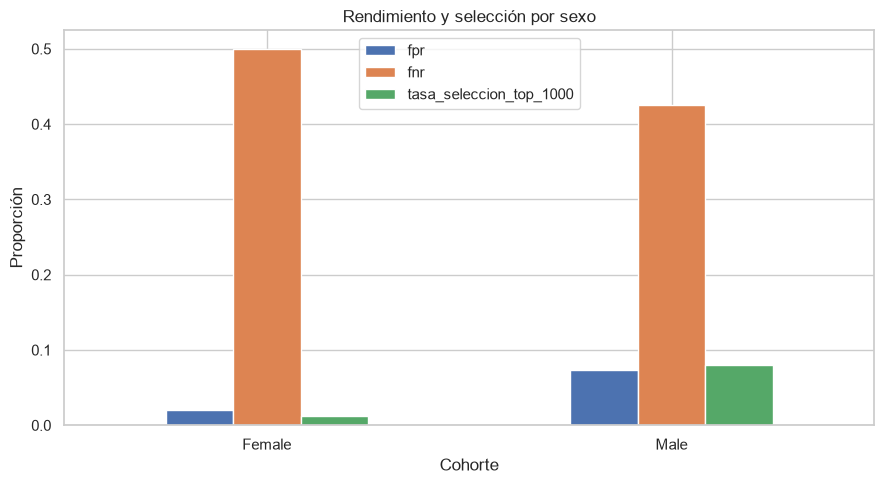

In [33]:
sex_metrics = (
    cohort_results
    .query("variable == 'sex' and metrica_estable == True")
    .set_index("cohorte")
)

sex_metrics[["fpr", "fnr", "tasa_seleccion_top_1000"]].plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Rendimiento y selección por sexo")
plt.ylabel("Proporción")
plt.xlabel("Cohorte")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

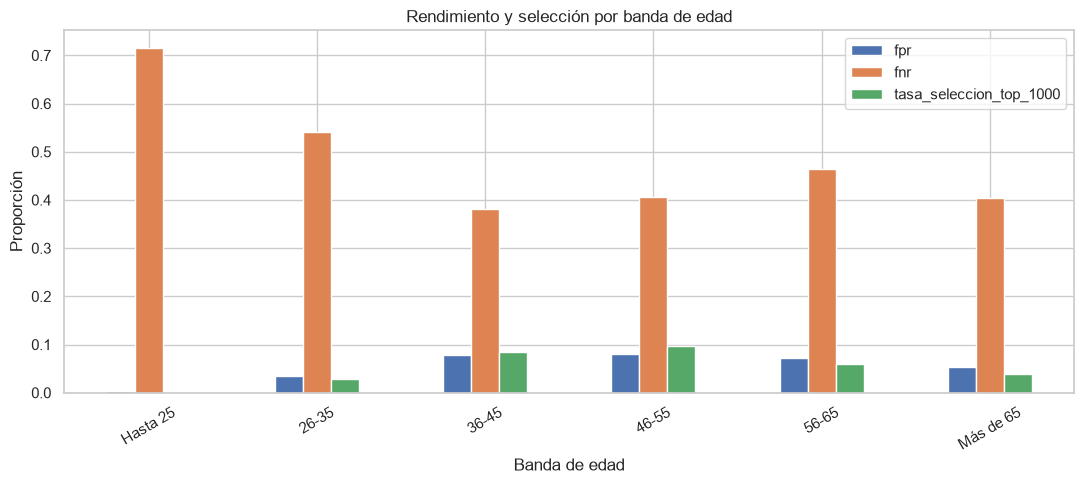

In [34]:
age_metrics = (
    cohort_results
    .query("variable == 'age_band' and metrica_estable == True")
    .set_index("cohorte")
)

age_metrics[["fpr", "fnr", "tasa_seleccion_top_1000"]].plot(
    kind="bar",
    figsize=(11, 5),
)

plt.title("Rendimiento y selección por banda de edad")
plt.ylabel("Proporción")
plt.xlabel("Banda de edad")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3.13 Interpretación del modelo

Para comprender qué información utiliza el Random Forest, analizamos la importancia
de sus variables.

La importancia indica cuánto utiliza el modelo una variable para realizar sus
divisiones. No demuestra que la variable sea causal ni que provoque la pertenencia
a la clase positiva.

In [35]:
fitted_preprocessor = best_rf.named_steps["prep"]
fitted_classifier = best_rf.named_steps["clf"]

transformed_feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": fitted_classifier.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance.sort_values("importance", ascending=False)

,feature,importance
2,num__capital_gain,0.238417
15,cat__marital_status_Married-civ-spouse,0.148773
1,num__education_num,0.144851
35,cat__relationship_Husband,0.074113
0,num__age,0.069798
3,num__capital_loss,0.068758
17,cat__marital_status_Never-married,0.032966
40,cat__relationship_Wife,0.022954
29,cat__occupation_Prof-specialty,0.022897
23,cat__occupation_Exec-managerial,0.021940


In [36]:
original_columns = list(X_train.columns)


def get_original_variable(transformed_name):
    clean_name = transformed_name.split("__", 1)[-1]

    for column in sorted(original_columns, key=len, reverse=True):
        if clean_name == column or clean_name.startswith(f"{column}_"):
            return column

    return clean_name


feature_importance["variable_original"] = (
    feature_importance["feature"]
    .apply(get_original_variable)
)

importance_by_variable = (
    feature_importance
    .groupby("variable_original", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

importance_by_variable

,variable_original,importance
1,capital_gain,0.238417
4,marital_status,0.194052
6,relationship,0.145300
3,education_num,0.144851
5,occupation,0.082218
0,age,0.069798
2,capital_loss,0.068758
7,sex,0.033040
8,workclass,0.023566


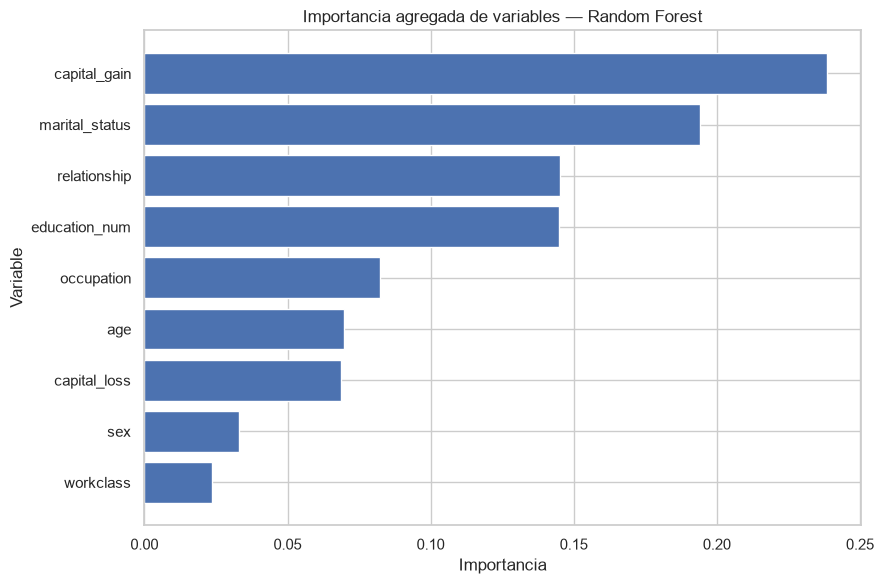

In [37]:
plot_data = (
    importance_by_variable
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(9, 6))
plt.barh(
    plot_data["variable_original"],
    plot_data["importance"],
)

plt.title("Importancia agregada de variables — Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 3.14 Conclusiones del análisis de errores y cohortes

### Rendimiento general

El Random Forest tuneado obtuvo, mediante predicciones out-of-fold, un
**ROC-AUC de 0.904**, un **PR-AUC de 0.805**, un **F1 de 0.657** y una
**accuracy de 0.848**.

Con un umbral de clasificación de 0.5, el modelo alcanzó una precision de
**0.795** y un recall de **0.561**. Esto indica que el modelo prioriza
relativamente la precision: la mayoría de los casos que clasifica como positivos
son efectivamente positivos, aunque deja sin detectar una proporción considerable
de los positivos existentes.

La matriz de confusión obtenida contiene:

- **12.583 verdaderos negativos**;
- **2.624 verdaderos positivos**;
- **677 falsos positivos**;
- **2.057 falsos negativos**.

En términos del caso de uso, la **Precision@1000 fue de 0.998**. Por lo tanto,
entre los 1000 casos con mayor riesgo estimado, aproximadamente **998 pertenecen
realmente a la clase positiva**.

El **Recall@1000 fue de 0.213**, lo que significa que esos 1000 casos concentran
aproximadamente el **21.3% de todos los casos positivos** del conjunto de
validación.

El **Lift@1000 fue de 3.825**. Esto indica que seleccionar los 1000 primeros
casos del ranking produce una precision aproximadamente **3.8 veces mayor que
una selección aleatoria**.

### Falsos positivos

Los falsos positivos se concentran principalmente en perfiles que el modelo
asocia fuertemente con la clase positiva: personas casadas, con niveles educativos
altos y ocupaciones profesionales o gerenciales.

El **98.8% de los falsos positivos** pertenece a la categoría
`Married-civ-spouse`. Además, las ocupaciones más frecuentes entre estos errores
son `Prof-specialty`, con **37.1%**, y `Exec-managerial`, con **29.6%**.

Las tasas de falsos positivos también son mayores en las cohortes con educación
superior. La FPR fue de **0.261 para personas con posgrado** y de **0.154 para
personas con grado universitario**, frente a **0.001 para personas con secundario
incompleto**.

Por ocupación, las mayores tasas de falsos positivos aparecen en
`Prof-specialty`, con **0.176**, `Exec-managerial`, con **0.158**, y
`Tech-support`, con **0.133**. También se observa una FPR elevada de **0.215**
para trabajadores de la categoría `Self-emp-inc`.

Estos errores podrían generar auditorías innecesarias sobre perfiles que presentan
características similares a las de los casos positivos. Por este motivo, el modelo
no debería utilizarse para determinar automáticamente una infracción, sino solamente
para priorizar casos que posteriormente serían revisados por un auditor.

### Falsos negativos

Los falsos negativos presentan, en promedio, menor nivel educativo y valores mucho
menores de ganancias de capital que los verdaderos positivos.

Los falsos negativos tienen un `education_num` promedio de **10.59**, mientras
que los verdaderos positivos presentan un promedio de **12.46**. La ganancia de
capital promedio es de **226.21** entre los falsos negativos y de **8896.63**
entre los verdaderos positivos.

Los casos positivos que no presentan ganancias de capital, tienen menor educación
o pertenecen a ocupaciones asociadas normalmente con ingresos bajos resultan más
difíciles de detectar para el modelo.

Las mayores tasas de falsos negativos por ocupación aparecen en:

- `Handlers-cleaners`: **0.831**;
- `Other-service`: **0.829**;
- `Machine-op-inspct`: **0.745**;
- `Farming-fishing`: **0.713**;
- `Transport-moving`: **0.710**.

También se observa una FNR de **0.716** entre las personas de hasta 25 años,
de **0.788** entre quienes tienen secundario incompleto y de **0.664** entre
los casos sin datos laborales.

Esto indica que el modelo tiene dificultades para identificar positivos que no
presentan los indicadores económicos, educativos o laborales más habituales de
la clase positiva. Una estrategia real no debería eliminar otros mecanismos de
selección de auditorías, ya que estos perfiles podrían quedar sistemáticamente
fuera del ranking.

### Cohortes

El rendimiento del modelo no es homogéneo entre las distintas cohortes.

Para las mujeres, el recall fue de **0.497** y la tasa de falsos negativos fue
de **0.503**. Para los hombres, el recall fue de **0.574** y la tasa de falsos
negativos fue de **0.426**. Por lo tanto, el modelo deja sin detectar una
proporción mayor de los casos positivos femeninos.

En sentido contrario, la tasa de falsos positivos fue mayor para los hombres:
**0.072**, frente a **0.020** para las mujeres.

La tasa de selección dentro del top 1000 fue de **8.0% para los hombres** y de
**1.2% para las mujeres**. Parte de esta diferencia puede relacionarse con la
prevalencia de la clase positiva en el dataset, que es de **32.8% para los hombres**
y de **13.8% para las mujeres**. Sin embargo, esta diferencia debería monitorearse
si el modelo se utilizara en una aplicación real.

Por edad, el modelo presenta su mayor tasa de falsos negativos entre las personas
de hasta 25 años, con **0.716**, seguidas por el grupo de 26 a 35 años, con
**0.543**. Las bandas de 36 a 45 y de 46 a 55 años son seleccionadas con mayor
frecuencia dentro del top 1000, con tasas de **8.5%** y **9.6%**, respectivamente.

Por educación, la tasa de selección aumenta fuertemente con el nivel educativo:
es de **0.2% para secundario incompleto**, **2.5% para secundario completo**,
**11.2% para grado universitario** y **19.0% para posgrado**. Este comportamiento
coincide con las diferencias de prevalencia entre estas cohortes, pero también
muestra que el ranking depende fuertemente de la educación.

### Variables relevantes

Las variables con mayor importancia agregada para el Random Forest fueron:

1. `capital_gain`: **0.239**;
2. `marital_status`: **0.194**;
3. `relationship`: **0.146**;
4. `education_num`: **0.145**;
5. `occupation`: **0.082**;
6. `age`: **0.070**;
7. `capital_loss`: **0.069**.

Las categorías individuales más importantes incluyen
`Married-civ-spouse`, `Husband`, `Never-married`, `Wife`,
`Prof-specialty` y `Exec-managerial`.

Estos resultados muestran que el modelo utiliza principalmente información sobre
ganancias de capital, educación, situación familiar y ocupación para construir el
ranking.

Estas importancias describen asociaciones predictivas dentro del dataset. No
demuestran que esas variables sean causas de ingresos altos ni de subdeclaración,
y no deberían utilizarse de manera aislada para justificar una auditoría.

## 3.15 Evaluación final sobre test

El conjunto de test se mantuvo aislado durante la selección de hiperparámetros,
la comparación out-of-fold y el análisis de errores. En esta sección se consulta
una única vez para obtener una estimación final del desempeño del Random Forest
ya elegido.

Se utiliza `best_rf = rf_search.best_estimator_`, que `RandomizedSearchCV` ya
refitó sobre todo `X_train` al finalizar la búsqueda. No se vuelven a seleccionar
hiperparámetros, a entrenar el modelo ni a modificar el umbral con información de
test: se aplica el umbral fijo de 0.5 definido en la evaluación anterior.

In [38]:
# Consulta final y única del conjunto de test; este bloque no ajusta el modelo.
best_rf = rf_search.best_estimator_
proba_test_rf = best_rf.predict_proba(X_test)[:, 1]
pred_test_rf = (proba_test_rf >= 0.5).astype(int)

test_metrics_rf_all = evaluate_oof_model(
    y_test,
    pred_test_rf,
    proba_test_rf,
)

final_metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "precision_at_1000",
    "recall_at_1000",
    "lift_at_1000",
]

metrics_test_rf = pd.DataFrame(
    [test_metrics_rf_all],
    index=["Random Forest (test)"],
)[final_metric_columns]

metrics_test_rf.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc,precision_at_1000,recall_at_1000,lift_at_1000
Random Forest (test),0.853,0.808,0.572,0.67,0.909,0.817,0.753,0.643,2.885


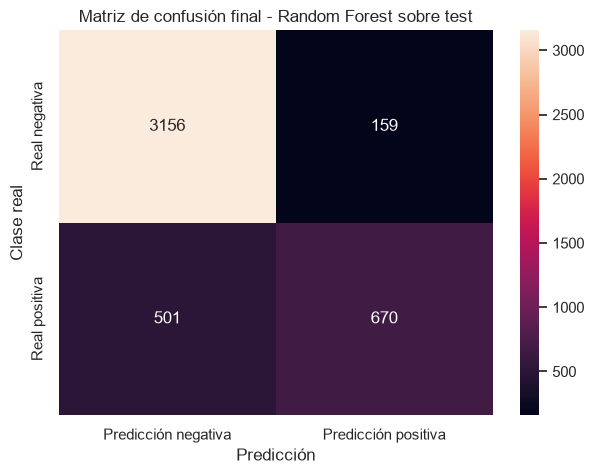

,Predicción negativa,Predicción positiva
Real negativa,3156,159
Real positiva,501,670


,accuracy,precision,recall,f1,roc_auc,pr_auc,precision_at_1000,recall_at_1000,lift_at_1000
Random Forest (OOF),0.848,0.795,0.561,0.657,0.904,0.805,0.998,0.213,3.825
Random Forest (test),0.853,0.808,0.572,0.670,0.909,0.817,0.753,0.643,2.885


Comparación breve OOF vs. test (test - OOF):


,diferencia
accuracy,0.005
precision,0.013
recall,0.012
f1,0.013
roc_auc,0.005
pr_auc,0.012
precision_at_1000,-0.245
recall_at_1000,0.430
lift_at_1000,-0.940


Las métricas de umbral y las AUC permanecen cercanas, con diferencias de hasta 0.013 a favor de test.
El top-1000 cubre 5.6% de OOF y 22.3% de test; por eso sus métricas de ranking no son directamente comparables y sus diferencias no representan por sí solas degradación.
La consulta a test no se usa para cambiar el modelo, sus hiperparámetros ni el umbral.


In [39]:
cm_test_rf = confusion_matrix(y_test, pred_test_rf, labels=[0, 1])
cm_test_rf_df = pd.DataFrame(
    cm_test_rf,
    index=["Real negativa", "Real positiva"],
    columns=["Predicción negativa", "Predicción positiva"],
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_test_rf_df, annot=True, fmt="d")
plt.title("Matriz de confusión final - Random Forest sobre test")
plt.ylabel("Clase real")
plt.xlabel("Predicción")
plt.show()

display(cm_test_rf_df)

comparacion_oof_test_rf = pd.concat([
    metrics_tuned.loc[["Random Forest"], final_metric_columns]
    .rename(index={"Random Forest": "Random Forest (OOF)"}),
    metrics_test_rf,
])

display(comparacion_oof_test_rf.round(3))

diferencias_oof_test = (
    comparacion_oof_test_rf.loc["Random Forest (test)"]
    - comparacion_oof_test_rf.loc["Random Forest (OOF)"]
)

print("Comparación breve OOF vs. test (test - OOF):")
display(diferencias_oof_test.to_frame("diferencia").round(3))
print(
    "Las métricas de umbral y las AUC permanecen cercanas, con diferencias "
    "de hasta 0.013 a favor de test."
)
print(
    f"El top-1000 cubre {1000 / len(y_train):.1%} de OOF y "
    f"{1000 / len(y_test):.1%} de test; por eso sus métricas de ranking no "
    "son directamente comparables y sus diferencias no representan por sí "
    "solas degradación."
)
print(
    "La consulta a test no se usa para cambiar el modelo, sus hiperparámetros "
    "ni el umbral."
)

## 3.16 Persistencia e inferencia sobre casos nuevos

Para usar el modelo sin volver a ejecutar entrenamiento, se persiste el `Pipeline`
completo. El artefacto contiene el preprocesamiento ya ajustado — selección de
variables, escalado y categorías del one-hot encoding — junto con el Random
Forest. De esta forma una fila nueva recibe exactamente las transformaciones
aprendidas sobre `X_train`.

El umbral de ingresos del target continúa siendo **50K**. El umbral de decisión
0.5 es distinto: determina desde qué probabilidad se asigna la clase positiva.
La probabilidad puede utilizarse directamente para construir el ranking.

In [40]:
from model_serving import predict_one, predict_rows, save_model_bundle

MODEL_ARTIFACT_PATH = save_model_bundle(best_rf)

new_row = [
    47, "Private", 120939, "Some-college", 10,
    "Married-civ-spouse", "Tech-support", "Husband",
    "White", "Male", 0, 0, 45, "United-States",
]

example_probability = predict_one(new_row, MODEL_ARTIFACT_PATH)
example_prediction = predict_rows(new_row, MODEL_ARTIFACT_PATH)

print(f"Artefacto guardado en: {MODEL_ARTIFACT_PATH}")
print(f"Probabilidad estimada de income >50K: {example_probability:.3f}")
display(example_prediction)

Artefacto guardado en: artifacts/random_forest_income.joblib
Probabilidad estimada de income >50K: 0.536


,probability_above_50k,prediction_above_50k
0,0.535945,1


La misma interfaz acepta un diccionario o un `DataFrame` con múltiples filas.
Los campos que el modelo descartó (`fnlwgt`, `education`, `race`,
`hours_per_week` y `native_country`) pueden llegar en la entrada cruda, pero no
participan de la predicción. Las categorías nuevas son tratadas por el
`OneHotEncoder(handle_unknown="ignore")` ya almacenado en el artefacto; no se
vuelve a ajustar el encoder durante inferencia.

## 4. Uso real, riesgos y monitoreo

### Alcance y operación

En un escenario ficticio de ARCA, los nuevos casos deberían ingresar con el
mismo contrato de datos utilizado para entrenar: mismas variables, tipos,
categorías admitidas, tratamiento de faltantes y transformaciones del pipeline
ajustado sobre `X_train`. Antes de calcular scores, el proceso debe validar
esquema, unicidad de identificadores, rangos plausibles (por ejemplo, edad y
montos), tasas de valores faltantes, categorías nuevas y consistencia entre
campos laborales y familiares. Un lote que no cumpla estas reglas debe quedar
retenido y trazado, no ser imputado silenciosamente ni enviado a priorización.

El consumidor es un equipo de fiscalización que administra una capacidad limitada
de revisión. El score debe producir un ranking o una cola de casos para revisar,
con evidencia y datos de contexto disponibles para el analista. El top-N es una
priorización de recursos, no una determinación: toda apertura, requerimiento o
medida posterior exige revisión humana, documentación y aplicación de las reglas
vigentes. El sistema nunca debe imponer una sanción automática ni usar el score
como única justificación de una auditoría. El tamaño del top-N debe responder a
la capacidad efectiva de revisión; el valor 1000 usado en este trabajo es una
métrica académica y no un cupo operativo validado.

En producción, la etiqueta tampoco puede ser `income >50K`: debería definirse
antes del desarrollo a partir de un resultado fiscal verificable y jurídicamente
pertinente, observado después de la fecha de scoring. Como solo maduran etiquetas
de casos revisados y pueden existir apelaciones o expedientes abiertos, se debe
separar casos resueltos de resultados todavía censurados y auditar una muestra
aleatoria fuera del ranking. Sin ese control, el modelo aprende de sus propias
selecciones y su recall real queda sin observar.

### Monitoreo

En cada corrida se deben registrar versión de datos, versión del pipeline y del
modelo, fecha, cantidad de casos, errores de validación y distribución de scores.
Se monitorearán la completitud y las categorías desconocidas de cada input, drift
de variables numéricas y categóricas respecto de entrenamiento, la prevalencia de
scores altos, la composición y estabilidad del top-N, y la tasa de selección por
cohorte. Deben distinguirse tres problemas: *data drift* cuando cambia la entrada,
*performance drift* cuando empeoran los resultados con etiquetas maduras y
*concept drift* cuando cambia la relación entre los datos y el resultado fiscal.
Como umbrales iniciales de investigación, resultan razonables más de 5 puntos
porcentuales de aumento en faltantes o categorías desconocidas, un PSI mayor a
0.20 en una variable crítica o una variación mayor al 15% en la composición del
top-N sin explicación operativa. Una falla de esquema retiene el lote; un drift
aislado abre investigación y dos ventanas consecutivas activan revisión formal.
Estos valores son disparadores preliminares que deben calibrarse por volumen y
estacionalidad, no límites universales ni decisiones automáticas.

Las etiquetas de resultado de una auditoría llegan con demora y pueden estar
sesgadas por las propias reglas de selección. Cuando estén disponibles, se deben
medir precision, recall, F1, ROC-AUC, PR-AUC, Precision@1000, Recall@1000 y
Lift@1000 en ventanas temporales y contra una muestra de control revisada fuera
del ranking. También corresponde seguir calibración por rangos de score y
performance, tasas de selección, FPR y FNR por cohortes; resultados inestables
por pocos casos deben marcarse como tales y no interpretarse como evidencia. Una
caída relativa mayor al 10% en Precision@N o PR-AUC durante dos ventanas maduras,
o una brecha relativa de FPR/FNR mayor al 20% entre cohortes con tamaño suficiente,
debe escalarse al comité responsable para reducir el cupo, volver temporalmente a
reglas manuales o suspender el modelo según impacto. La brecha es un disparador de
revisión, no una definición jurídica de discriminación.

El responsable operativo debería revisar calidad y salidas en cada corrida, y un
comité con fiscalización, datos, seguridad y asesoría legal revisar mensualmente
las alertas y trimestralmente las métricas ya maduras. Se propone evaluar un
reentrenamiento semestral, pero ejecutarlo solo si existe una muestra suficiente de
etiquetas cerradas o si dos ventanas confirman degradación, drift de concepto, un
cambio normativo, una nueva fuente o una modificación del etiquetado. Reentrenar
por calendario sin causa y con expedientes abiertos incorporaría ruido y sesgo.
Toda versión candidata requiere datos fechados, nueva validación temporal,
evaluación de sesgo, aprobación humana y registro de versión. Ningún modelo nuevo
debe reemplazar al anterior sin comparación reproducible, plan de reversión,
controles de acceso, retención acotada de datos y auditoría de quién consultó o
utilizó cada score.

### Riesgos éticos, legales y prácticos

`sex` es una variable sensible y no debe tratarse como una señal de riesgo fiscal.
Su uso en decisiones de priorización puede generar trato dispar y, aun si se
excluyera del entrenamiento, debe conservarse bajo controles de acceso para
auditar impactos por cohorte. En este dataset, `marital_status`, `relationship`,
educación y `occupation` también son especialmente problemáticas: describen
situaciones personales y socioeconómicas, pueden actuar como proxies de sexo u
otras características protegidas, y mostraron relevancia en el modelo y diferencias
de errores por cohorte. Deben someterse a revisión legal y de necesidad, pruebas
de ablation, límites explícitos de uso y monitoreo de impacto antes de cualquier
despliegue. No alcanza con quitar `sex` si los proxies conservan el mismo efecto.

Además, Adult/Census Income es un dataset de Estados Unidos y su target representa
ingresos superiores a 50K. No mide ni valida subdeclaración fiscal argentina, por
lo que este ejercicio no puede respaldar un sistema real de ARCA. Para un uso
operativo harían falta una definición legal y auditable del objetivo, datos
argentinos pertinentes y lícitamente obtenidos, evaluación temporal, evaluación
independiente de sesgo y garantías de debido proceso, privacidad y seguridad.
También persisten riesgos de datos desactualizados, errores de registro,
realimentación por seleccionar solo casos de alto score y sobrecarga del equipo
revisor; por eso el ranking debe complementar, y no reemplazar, controles y
criterios humanos independientes. Antes de cualquier piloto deben compararse,
como mínimo, el modelo actual y alternativas sin `sex` y sin los proxies más
problemáticos; mantenerlos exige demostrar necesidad, proporcionalidad y una
mejora que no pueda lograrse con señales fiscales menos intrusivas.

## 4.1 Simulación de adaptación, validación y test en producción

`extra-data.csv` contiene 16.281 observaciones etiquetadas que no participaron del
entrenamiento inicial. Como no incluye fechas, no permite una validación temporal
real; se utiliza para simular tres momentos mediante una división estratificada y
reproducible: **50% adaptación, 25% validation y 25% test final**.

Para desarrollar la versión V2, el antiguo `X_test` deja de cumplir el rol de test
y pasa a ser información histórica. El desarrollo reúne `X_train`, el antiguo
`X_test` y el lote de adaptación. Dentro de ese conjunto, K-fold compara un
reentrenamiento base contra una estrategia que da mayor peso a cohortes con FNR
alta. La selección usa las mismas métricas del desarrollo inicial: accuracy,
precision, recall, F1, ROC-AUC y PR-AUC, con **ROC-AUC como criterio principal**.

Validation compara los modelos congelados sobre exactamente las mismas filas y
elige uno. Test permanece aislado y se utiliza una sola vez para reportar el
rendimiento del modelo ya elegido; nunca interviene en la selección.


In [41]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate
from model_serving import load_labeled_csv, load_model_bundle

extra_raw, X_extra, y_extra = load_labeled_csv("extra-data.csv")

X_extra_adaptation, X_extra_reserved, y_extra_adaptation, y_extra_reserved = (
    train_test_split(
        X_extra,
        y_extra,
        test_size=0.50,
        stratify=y_extra,
        random_state=RANDOM_STATE,
    )
)

X_extra_validation, X_extra_test, y_extra_validation, y_extra_test = (
    train_test_split(
        X_extra_reserved,
        y_extra_reserved,
        test_size=0.50,
        stratify=y_extra_reserved,
        random_state=RANDOM_STATE,
    )
)

assert set(X_extra_adaptation.index).isdisjoint(X_extra_validation.index)
assert set(X_extra_adaptation.index).isdisjoint(X_extra_test.index)
assert set(X_extra_validation.index).isdisjoint(X_extra_test.index)

production_model = load_model_bundle(MODEL_ARTIFACT_PATH)["model"]

MODEL_SELECTION_METRICS = [
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
]


def evaluate_batch(model, X_batch, y_batch):
    probabilities = model.predict_proba(X_batch)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    metrics = pd.Series({
        "accuracy": accuracy_score(y_batch, predictions),
        "precision": precision_score(y_batch, predictions, zero_division=0),
        "recall": recall_score(y_batch, predictions, zero_division=0),
        "f1": f1_score(y_batch, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_batch, probabilities),
        "pr_auc": average_precision_score(y_batch, probabilities),
    })
    return metrics[MODEL_SELECTION_METRICS], probabilities, predictions


print("Extra data total:", len(X_extra))
print("Adaptación:", len(X_extra_adaptation))
print("Validation:", len(X_extra_validation))
print("Test final reservado:", len(X_extra_test))


Extra data total: 16281
Adaptación: 8140
Validation: 4070
Test final reservado: 4071


### 4.1.1 Cohortes problemáticas en adaptación

Las cohortes se descubren únicamente en el 50% de adaptación, utilizando las
predicciones del modelo productivo y etiquetas que se consideran maduras. Para
evitar decisiones basadas en grupos pequeños, se exigen al menos 100 casos, 20
positivos y 20 negativos. Se selecciona como máximo una cohorte por variable y se
prioriza la mayor tasa de falsos negativos (`fnr`).

Todos los casos de adaptación se incorporan una vez al desarrollo V2. Además, se
toma una muestra de hasta 250 casos por cohorte problemática y se les asigna peso
2 en la estrategia dirigida. Así se compara agregar datos nuevos normalmente
contra enfatizar cohortes, sin eliminar el resto de la distribución.


In [42]:
PRODUCTION_TOP_N = 1000
production_cohort_columns = [
    "sex", "age_band", "education_band",
    "datos_laborales", "occupation",
]


def build_batch_cohorts(X_batch, y_batch, model):
    data = X_batch.copy()
    data["y_real"] = y_batch.to_numpy()
    data["probabilidad"] = model.predict_proba(X_batch)[:, 1]
    data["prediccion"] = (data["probabilidad"] >= 0.5).astype(int)
    data["age_band"] = pd.cut(
        data["age"],
        bins=[0, 25, 35, 45, 55, 65, np.inf],
        labels=["Hasta 25", "26-35", "36-45", "46-55", "56-65", "Más de 65"],
    )
    data["education_band"] = pd.cut(
        data["education_num"],
        bins=[0, 8, 9, 12, 13, 16],
        labels=[
            "Secundario incompleto", "Secundario completo",
            "Estudios superiores incompletos", "Grado universitario",
            "Posgrado",
        ],
        include_lowest=True,
    )
    data["datos_laborales"] = np.where(
        (data["workclass"] == "Sin_dato")
        | (data["occupation"] == "Sin_dato"),
        "Sin dato laboral",
        "Con dato laboral",
    )
    top_n = min(PRODUCTION_TOP_N, len(data))
    top_indices = data.nlargest(top_n, "probabilidad").index
    data["top_1000"] = data.index.isin(top_indices)

    cohort_metrics = pd.concat(
        [metrics_by_cohort(data, column) for column in production_cohort_columns],
        ignore_index=True,
    )
    return data, cohort_metrics


adaptation_analysis, adaptation_cohorts = build_batch_cohorts(
    X_extra_adaptation, y_extra_adaptation, production_model
)

eligible_cohorts = adaptation_cohorts.query(
    "n >= 100 and positivos >= 20 and negativos >= 20"
)
problem_cohorts = (
    eligible_cohorts
    .sort_values("fnr", ascending=False)
    .groupby("variable", group_keys=False)
    .head(1)
    .sort_values("fnr", ascending=False)
    .head(4)
)

display(problem_cohorts[[
    "variable", "cohorte", "n", "positivos",
    "precision", "recall", "fpr", "fnr",
]].round(3))

emphasis_indices = []
for offset, cohort in problem_cohorts.reset_index(drop=True).iterrows():
    cohort_mask = (
        adaptation_analysis[cohort["variable"]].astype(str)
        == str(cohort["cohorte"])
    )
    cohort_indices = adaptation_analysis.index[cohort_mask].to_series()
    selected = cohort_indices.sample(
        n=min(250, len(cohort_indices)),
        random_state=RANDOM_STATE + offset,
    )
    emphasis_indices.extend(selected.tolist())

emphasis_indices = pd.Index(emphasis_indices).unique()
print("Casos de adaptación con peso reforzado:", len(emphasis_indices))


,variable,cohorte,n,positivos,precision,recall,fpr,fnr
29,occupation,Transport-moving,383,91,0.889,0.176,0.007,0.824
8,education_band,Secundario incompleto,1086,56,0.769,0.179,0.003,0.821
14,datos_laborales,Sin dato laboral,472,43,0.929,0.302,0.002,0.698
7,age_band,Más de 65,351,65,0.686,0.369,0.038,0.631


Casos de adaptación con peso reforzado: 930


### 4.1.2 Desarrollo V2 con K-fold

El desarrollo V2 contiene todos los datos históricos y todo el lote de adaptación.
El pipeline se vuelve a ajustar dentro de cada fold, por lo que el scaler y el
one-hot encoder nunca se entrenan con el fold de validación. Los folds se
estratifican simultáneamente por target y origen de los datos para conservar la
proporción de casos históricos y nuevos.

Se comparan dos estrategias con los hiperparámetros del Random Forest ya elegidos:

- **Reentrenado base:** todas las observaciones tienen peso 1.
- **Ponderado por cohortes:** los casos seleccionados en adaptación tienen peso 2.

ROC-AUC mantiene el rol de métrica primaria; las demás métricas permiten verificar
que una mejora de ranking no oculte deterioros de clasificación.


In [43]:
X_development_v2 = pd.concat(
    [X_train, X_test, X_extra_adaptation],
    ignore_index=True,
)
y_development_v2 = pd.concat(
    [y_train, y_test, y_extra_adaptation],
    ignore_index=True,
)

historical_size = len(X_train) + len(X_test)
development_source = pd.Series(
    ["historical"] * historical_size
    + ["adaptation"] * len(X_extra_adaptation)
)
development_strata = (
    development_source + "_" + y_development_v2.astype(str)
)

cv_v2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)
cv_v2_splits = list(cv_v2.split(X_development_v2, development_strata))

selection_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

development_weights = np.ones(len(X_development_v2))
adaptation_emphasis_mask = X_extra_adaptation.index.isin(emphasis_indices)
emphasis_positions = (
    historical_size + np.flatnonzero(adaptation_emphasis_mask)
)
development_weights[emphasis_positions] = 2.0

baseline_cv = cross_validate(
    clone(production_model),
    X_development_v2,
    y_development_v2,
    cv=cv_v2_splits,
    scoring=selection_scoring,
    n_jobs=1,
)
cohort_cv = cross_validate(
    clone(production_model),
    X_development_v2,
    y_development_v2,
    cv=cv_v2_splits,
    scoring=selection_scoring,
    n_jobs=1,
    params={"clf__sample_weight": development_weights},
)


def summarize_cv(result):
    return {
        metric: result[f"test_{metric}"].mean()
        for metric in MODEL_SELECTION_METRICS
    }


cv_v2_comparison = pd.DataFrame({
    "Reentrenado base": summarize_cv(baseline_cv),
    "Ponderado por cohortes": summarize_cv(cohort_cv),
}).T
display(cv_v2_comparison.round(3))

baseline_retrained = clone(production_model)
baseline_retrained.fit(X_development_v2, y_development_v2)

cohort_candidate = clone(production_model)
_ = cohort_candidate.fit(
    X_development_v2,
    y_development_v2,
    clf__sample_weight=development_weights,
)


,accuracy,precision,recall,f1,roc_auc,pr_auc
Reentrenado base,0.853,0.799,0.566,0.663,0.907,0.805
Ponderado por cohortes,0.853,0.801,0.559,0.659,0.907,0.805


### 4.1.3 Comparación y selección en validation

El productivo actual, el reentrenado base y el ponderado por cohortes reciben las
mismas 4.070 filas crudas de validation. Cada uno aplica su propio pipeline y se
evalúa contra las mismas etiquetas. Las métricas históricas del productivo no se
usan para esta decisión: se recalculan sobre este lote común.

La regla de promoción se define antes de abrir test. El mejor candidato por
ROC-AUC debe superar al productivo por al menos 0.005 y no degradar PR-AUC ni F1
en más de 0.005. Ante empate o evidencia insuficiente se conserva el modelo actual.


,accuracy,precision,recall,f1,roc_auc,pr_auc
Productivo actual,0.872,0.827,0.582,0.683,0.918,0.811
Reentrenado base,0.872,0.829,0.575,0.679,0.919,0.814
Ponderado por cohortes,0.873,0.838,0.571,0.679,0.919,0.814


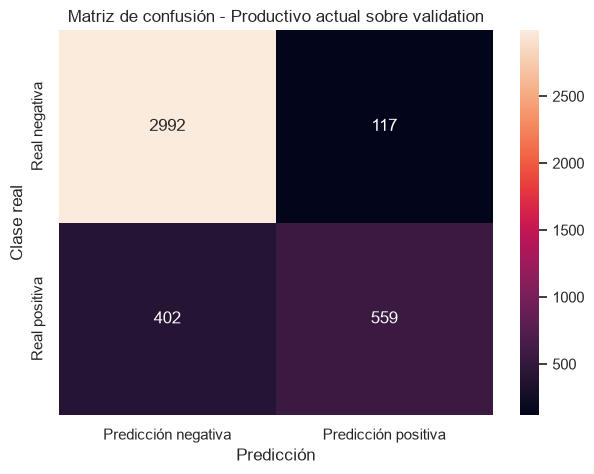

,Predicción negativa,Predicción positiva
Real negativa,2992,117
Real positiva,402,559


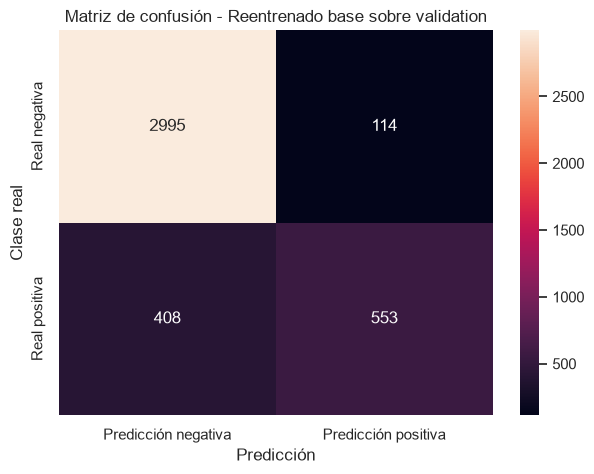

,Predicción negativa,Predicción positiva
Real negativa,2995,114
Real positiva,408,553


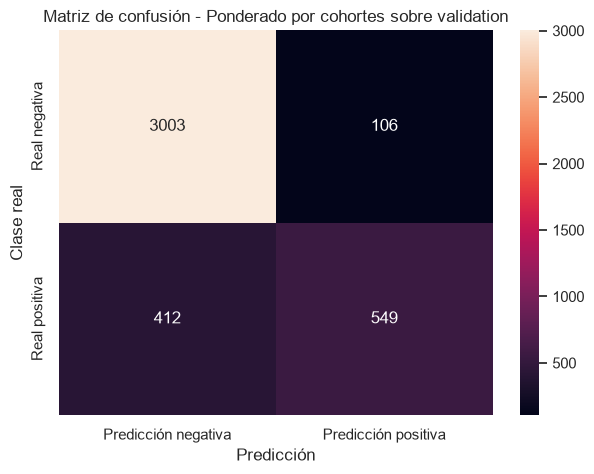

,Predicción negativa,Predicción positiva
Real negativa,3003,106
Real positiva,412,549


,delta_candidato_vs_productivo
accuracy,-0.001
precision,0.002
recall,-0.006
f1,-0.004
roc_auc,0.001
pr_auc,0.003


Mejor candidato en validation: Reentrenado base
Modelo seleccionado antes de abrir test: Productivo actual


,variable,cohorte,n,positivos,recall_productivo,fnr_productivo,recall_candidato,fnr_candidato,delta_fnr
0,occupation,Transport-moving,186,30,0.100,0.900,0.100,0.900,0.000
1,education_band,Secundario incompleto,528,36,0.222,0.778,0.222,0.778,0.000
2,datos_laborales,Sin dato laboral,237,10,0.300,0.700,0.300,0.700,0.000
3,age_band,Más de 65,155,28,0.536,0.464,0.571,0.429,-0.036


In [44]:
validation_models = {
    "Productivo actual": production_model,
    "Reentrenado base": baseline_retrained,
    "Ponderado por cohortes": cohort_candidate,
}

validation_evaluations = {
    name: evaluate_batch(model, X_extra_validation, y_extra_validation)
    for name, model in validation_models.items()
}
validation_results = pd.DataFrame({
    name: evaluation[0]
    for name, evaluation in validation_evaluations.items()
}).T
display(validation_results.round(3))


def plot_confusion_matrices(y_true, predictions_by_model, stage):
    matrices = {}

    for model_name, predictions in predictions_by_model.items():
        matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
        matrix_df = pd.DataFrame(
            matrix,
            index=["Real negativa", "Real positiva"],
            columns=["Predicción negativa", "Predicción positiva"],
        )
        matrices[model_name] = matrix_df

        plt.figure(figsize=(7, 5))
        sns.heatmap(matrix_df, annot=True, fmt="d")
        plt.title(f"Matriz de confusión - {model_name} sobre {stage}")
        plt.ylabel("Clase real")
        plt.xlabel("Predicción")
        plt.show()
        display(matrix_df)

    return matrices


validation_confusion_matrices = plot_confusion_matrices(
    y_extra_validation,
    {
        name: evaluation[2]
        for name, evaluation in validation_evaluations.items()
    },
    stage="validation",
)

candidate_validation_results = validation_results.drop(
    index="Productivo actual"
)
best_candidate_name = (
    candidate_validation_results
    .sort_values(["roc_auc", "pr_auc", "f1"], ascending=False)
    .index[0]
)

validation_delta = (
    validation_results.loc[best_candidate_name]
    - validation_results.loc["Productivo actual"]
)
display(validation_delta.to_frame("delta_candidato_vs_productivo").round(3))

MIN_ROC_AUC_GAIN = 0.005
MAX_SECONDARY_DROP = 0.005
candidate_passes = (
    validation_delta["roc_auc"] >= MIN_ROC_AUC_GAIN
    and validation_delta["pr_auc"] >= -MAX_SECONDARY_DROP
    and validation_delta["f1"] >= -MAX_SECONDARY_DROP
)

if candidate_passes:
    selected_model_name = best_candidate_name
else:
    selected_model_name = "Productivo actual"

selected_model = validation_models[selected_model_name]
print("Mejor candidato en validation:", best_candidate_name)
print("Modelo seleccionado antes de abrir test:", selected_model_name)

_, production_validation_cohorts = build_batch_cohorts(
    X_extra_validation, y_extra_validation, production_model
)
_, candidate_validation_cohorts = build_batch_cohorts(
    X_extra_validation, y_extra_validation, validation_models[best_candidate_name]
)

cohort_keys = problem_cohorts[["variable", "cohorte"]]
validation_cohort_comparison = (
    cohort_keys
    .merge(
        production_validation_cohorts[[
            "variable", "cohorte", "n", "positivos", "recall", "fnr",
        ]],
        on=["variable", "cohorte"],
        how="left",
    )
    .merge(
        candidate_validation_cohorts[[
            "variable", "cohorte", "recall", "fnr",
        ]],
        on=["variable", "cohorte"],
        how="left",
        suffixes=("_productivo", "_candidato"),
    )
)
validation_cohort_comparison["delta_fnr"] = (
    validation_cohort_comparison["fnr_candidato"]
    - validation_cohort_comparison["fnr_productivo"]
)
display(validation_cohort_comparison.round(3))


### 4.1.4 Evaluación final en test

La selección terminó en validation. A continuación se evalúa **únicamente el
modelo seleccionado** sobre las 4.071 filas de test. Este resultado no se utiliza
para cambiar de modelo, ajustar hiperparámetros, modificar pesos ni alterar el
umbral. Si revela un problema, se reporta y el lote queda consumido para futuras
iteraciones.


,accuracy,precision,recall,f1,roc_auc,pr_auc
Productivo actual,0.868,0.806,0.583,0.677,0.923,0.813


Test evaluó solamente: Productivo actual


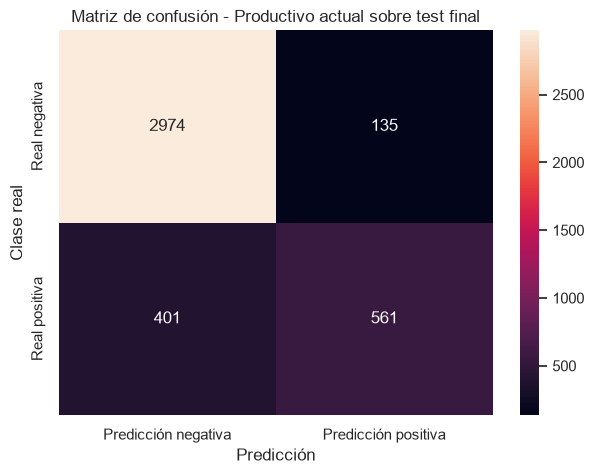

,Predicción negativa,Predicción positiva
Real negativa,2974,135
Real positiva,401,561


In [45]:
selected_test_metrics, _, selected_test_predictions = evaluate_batch(
    selected_model,
    X_extra_test,
    y_extra_test,
)

display(
    selected_test_metrics
    .to_frame(selected_model_name)
    .T
    .round(3)
)
print("Test evaluó solamente:", selected_model_name)

test_confusion_matrices = plot_confusion_matrices(
    y_extra_test,
    {selected_model_name: selected_test_predictions},
    stage="test final",
)


### 4.1.5 Lectura del experimento

En K-fold, el reentrenado base y el ponderado por cohortes obtuvieron el mismo
ROC-AUC redondeado de **0.907** y PR-AUC de **0.805**. El base conservó mejores
recall (**0.566 frente a 0.559**) y F1 (**0.663 frente a 0.659**), por lo que la
ponderación no mostró una ventaja durante desarrollo.

En validation, el reentrenado base fue el mejor candidato: alcanzó ROC-AUC 0.919
y PR-AUC 0.814, frente a 0.918 y 0.811 del productivo. Sin embargo, la mejora de
ROC-AUC fue solo **0.001**, menor que el mínimo predefinido de 0.005, y además
redujo recall de **0.582 a 0.575** y F1 de **0.683 a 0.679**. Por lo tanto, no
cumplió la regla de promoción y se mantuvo el **Productivo actual**.

La decisión quedó cerrada antes de abrir test. Las 4.071 filas finales evaluaron
únicamente al productivo seleccionado, que obtuvo accuracy 0.868, precision 0.806,
recall 0.583, F1 0.677, ROC-AUC 0.923 y PR-AUC 0.813. Estas métricas se reportan,
pero no alteran la selección.

La separación es una simulación académica porque las etiquetas de
`extra-data.csv` ya habían sido inspeccionadas en una versión previa del trabajo.
En producción, adaptación, validation y test deben ser ventanas nuevas
predefinidas, y cada test consumido debe reemplazarse por un período futuro no
observado.
